In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [2]:
# Importando as bibliotecas básicas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [3]:
# Importando as bibliotecas de Machine Learning

from matplotlib.ticker import MaxNLocator
from sklearn.model_selection import train_test_split, GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, mean_squared_error, r2_score, roc_auc_score, roc_curve

# Importa a biblioteca Boost
from xgboost import XGBRegressor, XGBClassifier
from catboost import CatBoostRegressor, CatBoostClassifier
from lightgbm import LGBMRegressor, LGBMClassifier

# Importa biblioteca joblib
import joblib

In [4]:
# Suprimindo avisos desnecessários durante os testes

import warnings
warnings.filterwarnings('ignore')

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# ── 1. Carregue o arquivo ──────────────────────────────────────────────
xl = pd.ExcelFile('/content/drive/MyDrive/Datathon-FIAP- fase 5/BASE DE DADOS PEDE 2024 - DATATHON.xlsx')
dfs = {sheet: pd.read_excel(xl, sheet_name=sheet) for sheet in xl.sheet_names}

In [8]:
# Entendendo o arquivo

for aba, df in dfs.items():
    linhas, colunas = df.shape
    print(f"Aba: {aba} | Linhas: {linhas} | Colunas: {colunas}")

Aba: PEDE2022 | Linhas: 860 | Colunas: 42
Aba: PEDE2023 | Linhas: 1014 | Colunas: 48
Aba: PEDE2024 | Linhas: 1156 | Colunas: 50


In [9]:
# Carregando as informações do arquivo

dfs['PEDE2022'].info()
dfs['PEDE2023'].info()
dfs['PEDE2024'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     860 non-null    object 
 1   Fase                   860 non-null    int64  
 2   Turma                  860 non-null    object 
 3   Nome                   860 non-null    object 
 4   Ano nasc               860 non-null    int64  
 5   Idade 22               860 non-null    int64  
 6   Gênero                 860 non-null    object 
 7   Ano ingresso           860 non-null    int64  
 8   Instituição de ensino  860 non-null    object 
 9   Pedra 20               323 non-null    object 
 10  Pedra 21               462 non-null    object 
 11  Pedra 22               860 non-null    object 
 12  INDE 22                860 non-null    float64
 13  Cg                     860 non-null    int64  
 14  Cf                     860 non-null    int64  
 15  Ct    

In [10]:
# Lista de colunas

print(list(dfs['PEDE2022'].columns))
print(list(dfs['PEDE2023'].columns))
print(list(dfs['PEDE2024'].columns))

['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']
['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', 'Defasagem', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 

Verificando se existem colunas inteiramente nulas

In [11]:
dfs['PEDE2022'].isnull().sum()

,0
RA,0
Fase,0
Turma,0
Nome,0
Ano nasc,0
Idade 22,0
Gênero,0
Ano ingresso,0
Instituição de ensino,0
Pedra 20,537


In [12]:
dfs['PEDE2023'].isnull().sum()

,0
RA,0
Fase,0
INDE 2023,83
Pedra 2023,83
Turma,0
Nome Anonimizado,0
Data de Nasc,0
Idade,0
Gênero,0
Ano ingresso,0


In [13]:
dfs['PEDE2024'].isnull().sum()

,0
RA,0
Fase,0
INDE 2024,64
Pedra 2024,64
Turma,0
Nome Anonimizado,0
Data de Nasc,0
Idade,0
Gênero,0
Ano ingresso,0


In [14]:
# Correções nos nomes das colunas:
correcoes_manuais = {
    'PEDE2022': {
        'Idade 22' : 'Idade',
        'Pedra 22' : 'Pedra',
        'Matem' : 'Mat',
        'Portug' : 'Por',
        'Inglês' : 'Ing',
        'Defas' : 'Defasagem',
        'INDE 22' : 'INDE',
        'Fase ideal' : 'Fase Ideal'
    },
    'PEDE2023': {
        'Nome Anonimizado': 'Nome',
        'INDE 2023' : 'INDE',
        'Pedra 2023' : 'Pedra'
    },
    'PEDE2024': {
        'Nome Anonimizado': 'Nome',
        'INDE 2024' : 'INDE',
        'Pedra 2024' : 'Pedra'
    },
}

for aba, correcoes in correcoes_manuais.items():
    if correcoes:
        dfs[aba] = dfs[aba].rename(columns=correcoes)

In [15]:
# Exibir colunas corrigidas

print(list(dfs['PEDE2022'].columns))
print(list(dfs['PEDE2023'].columns))
print(list(dfs['PEDE2024'].columns))

['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra', 'INDE', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', 'Defasagem', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']
['RA', 'Fase', 'INDE', 'Pedra', 'Turma', 'Nome', 'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', 'Defasagem', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'Destaque IPV.1']
['RA', 'Fase', 'I

In [16]:
# Separar cada dataset por ano

df_2022 = dfs['PEDE2022'].assign(ano=2022)
df_2023 = dfs['PEDE2023'].assign(ano=2023)
df_2024 = dfs['PEDE2024'].assign(ano=2024)

In [17]:
# Verificar se existem duplicadas

for aba, df in dfs.items():
    print(f"Aba: {aba} | Valores Duplicados: {df.duplicated().any()}")

Aba: PEDE2022 | Valores Duplicados: False
Aba: PEDE2023 | Valores Duplicados: False
Aba: PEDE2024 | Valores Duplicados: False


In [18]:
df_2022.columns

Index(['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade', 'Gênero',
       'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21',
       'Pedra', 'INDE', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1',
       'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4',
       'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Mat', 'Por',
       'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal',
       'Defasagem', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'ano'],
      dtype='object')

O dataset de 2022 não possui documentado 1 dos indicadores que compõem o INDE. Será necessário adicionar uma coluna calculada para trazer os dados de IPP e, posteriormente, treinar o modelo.

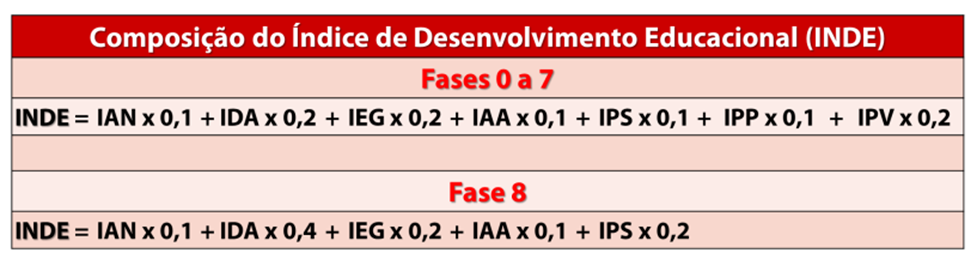

In [19]:
# Para Fases 0 a 7
mask = df_2022['Fase'] != 8

df_2022.loc[mask, 'IPP'] = (
    df_2022['INDE']
    - df_2022['IAN'] * 0.1
    - df_2022['IDA'] * 0.2
    - df_2022['IEG'] * 0.2
    - df_2022['IAA'] * 0.1
    - df_2022['IPS'] * 0.1
    - df_2022['IPV'] * 0.2
) / 0.1

# Para Fase 8 (IPP não entra na fórmula, então definimos como NaN)
df_2022.loc[~mask, 'IPP'] = None

In [20]:
# Colunas do dataset

print(df_2022.columns.tolist())
print(df_2023.columns.tolist())
print(df_2024.columns.tolist())

['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra', 'INDE', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', 'Defasagem', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'ano', 'IPP']
['RA', 'Fase', 'INDE', 'Pedra', 'Turma', 'Nome', 'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', 'Defasagem', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'Destaque IPV.1', 'an

In [21]:
# Colunas em comum entre os 3 dataframes

colunas_comuns = set(df_2022.columns) & set(df_2023.columns) & set(df_2024.columns)
print(colunas_comuns)

{'Indicado', 'Avaliador3', 'IDA', 'Defasagem', 'Turma', 'Pedra', 'Pedra 21', 'Rec Psicologia', 'Ing', 'IEG', 'Destaque IPV', 'Cg', 'IAN', 'INDE', 'Avaliador1', 'Rec Av2', 'Rec Av1', 'IAA', 'Mat', 'Fase', 'Destaque IDA', 'Gênero', 'Nº Av', 'Atingiu PV', 'Por', 'Instituição de ensino', 'Destaque IEG', 'Ano ingresso', 'RA', 'Ct', 'Idade', 'Avaliador4', 'Cf', 'IPP', 'Fase Ideal', 'ano', 'Avaliador2', 'Nome', 'IPV', 'IPS', 'Pedra 20'}


In [22]:
colunas_interesse = {'RA', 'ano', 'Fase', 'Turma', 'Nome', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Fase Ideal', 'Defasagem', 'INDE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'IPP', 'Pedra 20', 'Pedra 21', 'Pedra', 'Cg', 'Cf', 'Ct', 'Mat', 'Por', 'Ing'}

In [23]:
df_2022 = df_2022[list(colunas_interesse & set(df_2022.columns))]
df_2023 = df_2023[list(colunas_interesse & set(df_2023.columns))]
df_2024 = df_2024[list(colunas_interesse & set(df_2024.columns))]

In [24]:
print("Shape 2022:", df_2022.shape)
print("Shape 2023:", df_2023.shape)
print("Shape 2024:", df_2024.shape)

Shape 2022: (860, 28)
Shape 2023: (1014, 28)
Shape 2024: (1156, 28)


In [25]:
df_consolidado = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)
print(df_consolidado.shape)

(3030, 28)


In [26]:
print(df_consolidado.columns.tolist())

['IDA', 'Defasagem', 'Turma', 'Pedra', 'Pedra 21', 'Ing', 'IEG', 'Cg', 'IAN', 'INDE', 'IAA', 'Mat', 'Fase', 'Gênero', 'Por', 'Instituição de ensino', 'Ano ingresso', 'RA', 'Ct', 'Idade', 'Cf', 'IPP', 'Fase Ideal', 'ano', 'Nome', 'IPV', 'IPS', 'Pedra 20']


In [27]:
df_consolidado.describe()

,IDA,Defasagem,Ing,IEG,Cg,IAN,IAA,Mat,Por,Ano ingresso,Ct,Cf,IPP,ano,IPV,IPS
count,2852.000000,3030.000000,1091.000000,2954.000000,860.000000,3030.000000,2865.000000,2846.000000,2845.000000,3030.000000,860.000000,860.000000,2852.000000,3030.00000,2852.000000,2859.000000
mean,6.375964,-0.642904,6.289413,7.945696,430.516279,7.179043,7.918225,6.161595,6.430668,2021.563696,6.598837,75.519767,7.171427,2023.09769,7.545476,6.287129
std,1.956637,0.866382,2.732636,2.152281,248.432761,2.535266,2.626209,2.398341,2.138916,1.822171,3.975858,52.312670,1.159301,0.80995,1.084347,1.792491
min,0.000000,-5.000000,0.000000,0.000000,1.000000,2.500000,0.000000,0.000000,0.000000,2016.000000,1.000000,1.000000,-0.074000,2022.00000,2.500000,2.500000
25%,5.100000,-1.000000,4.500000,7.300000,215.750000,5.000000,7.900000,4.800000,5.200000,2021.000000,3.000000,30.000000,6.329500,2022.00000,6.984000,5.020000
50%,6.666667,-1.000000,6.700000,8.600000,430.500000,5.000000,8.751000,6.300000,6.700000,2022.000000,6.000000,67.000000,7.500000,2023.00000,7.583000,7.500000
75%,7.833333,0.000000,8.500000,9.400000,645.250000,10.000000,9.500000,8.000000,8.000000,2023.000000,9.000000,118.000000,7.968750,2024.00000,8.255000,7.510000
max,10.000000,3.000000,10.000000,10.000000,862.000000,10.000000,10.002000,10.000000,10.000000,2024.000000,18.000000,192.000000,10.000000,2024.00000,10.010000,10.000000


In [28]:
df_consolidado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   IDA                    2852 non-null   float64
 1   Defasagem              3030 non-null   int64  
 2   Turma                  3030 non-null   object 
 3   Pedra                  2883 non-null   object 
 4   Pedra 21               1061 non-null   object 
 5   Ing                    1091 non-null   float64
 6   IEG                    2954 non-null   float64
 7   Cg                     860 non-null    float64
 8   IAN                    3030 non-null   float64
 9   INDE                   2883 non-null   object 
 10  IAA                    2865 non-null   float64
 11  Mat                    2846 non-null   float64
 12  Fase                   3030 non-null   object 
 13  Gênero                 3030 non-null   object 
 14  Por                    2845 non-null   float64
 15  Inst

In [29]:
df_consolidado.isnull().sum()

,0
IDA,178
Defasagem,0
Turma,0
Pedra,147
Pedra 21,1969
Ing,1939
IEG,76
Cg,2170
IAN,0
INDE,147


In [30]:
df_consolidado.head()

,IDA,Defasagem,Turma,Pedra,Pedra 21,Ing,IEG,Cg,IAN,INDE,...,Ct,Idade,Cf,IPP,Fase Ideal,ano,Nome,IPV,IPS,Pedra 20
0,4.0,-1,A,Quartzo,Ametista,6.0,4.1,753.0,5.0,5.783,...,10.0,19,18.0,8.174,Fase 8 (Universitários),2022,Aluno-1,7.278,5.6,Ametista
1,6.8,0,A,Ametista,Ametista,9.7,5.2,469.0,10.0,7.055,...,3.0,17,8.0,7.894,Fase 7 (3º EM),2022,Aluno-2,6.778,6.3,Ametista
2,5.6,0,A,Ágata,Ametista,6.9,7.9,629.0,10.0,6.591,...,6.0,17,13.0,8.198,Fase 7 (3º EM),2022,Aluno-3,7.556,5.6,Ametista
3,5.0,0,A,Quartzo,Ametista,8.7,4.5,731.0,10.0,5.951,...,7.0,17,15.0,5.554,Fase 7 (3º EM),2022,Aluno-4,5.278,5.6,Ametista
4,5.2,0,A,Ametista,Ametista,5.7,8.6,344.0,10.0,7.427,...,2.0,17,6.0,8.392,Fase 7 (3º EM),2022,Aluno-5,7.389,5.6,Ametista


In [31]:
# Verificando as variáveis categóricas do dataframe

colunas_object = df_consolidado.select_dtypes(include='object').columns.tolist()
colunas_object

['Turma',
 'Pedra',
 'Pedra 21',
 'INDE',
 'Fase',
 'Gênero',
 'Instituição de ensino',
 'RA',
 'Idade',
 'Fase Ideal',
 'Nome',
 'Pedra 20']

As colunas Idade, Fase, Fase Ideal e INDE não deveriam ser do tipo 'object' ou 'string', deveriam ser do tipo 'float64' ou 'int64'. Precisamos verificar

1) Ajustando a coluna Fase:

In [32]:
#Visualizando os valores únicos das variáveis Fases
print(f'As fases possíveis: {df_consolidado.Fase.unique()}')

As fases possíveis: [7 6 5 4 3 2 1 0 'ALFA' 'FASE 1' 'FASE 2' 'FASE 3' 'FASE 4' 'FASE 5'
 'FASE 6' 'FASE 7' 'FASE 8' '1A' '1B' '1C' '1D' '1E' '1G' '1H' '1J' '1K'
 '1L' '1M' '1N' '1P' '1R' '2A' '2B' '2C' '2D' '2G' '2H' '2I' '2K' '2L'
 '2M' '2N' '2P' '2R' '2U' '3A' '3B' '3C' '3D' '3F' '3G' '3H' '3I' '3K'
 '3L' '3M' '3N' '3P' '3R' '3U' '4A' '4B' '4C' '4F' '4H' '4L' '4M' '4N'
 '4R' '5A' '5B' '5C' '5D' '5F' '5G' '5L' '5M' '5N' '6A' '6L' '7A' '7E'
 '8A' '8B' '8D' '8E' '8F' 9]


In [33]:
# Transformando os valores da coluna Fase

# Passo 1: Substituir ALFA por 0 antes de qualquer transformação
df_consolidado['Fase'] = df_consolidado['Fase'].replace('ALFA', 0)

# Passo 2: Extrair o primeiro dígito de forma vetorizada
df_consolidado['Fase'] = df_consolidado['Fase'].astype(str).str.extract(r'(\d)')[0].astype(float).astype(int)

print(f'As fases possíveis: {df_consolidado.Fase.unique()}')

As fases possíveis: [7 6 5 4 3 2 1 0 8 9]


2) Ajustando a coluna Fase Ideal:

In [34]:
#Visualizando os valores únicos das variáveis Fases
print(f'As fases possíveis: {df_consolidado['Fase Ideal'].unique()}')

As fases possíveis: ['Fase 8 (Universitários)' 'Fase 7 (3º EM)' 'Fase 6 (2º EM)'
 'Fase 5 (1º EM)' 'Fase 3 (7º e 8º ano)' 'Fase 4 (9º ano)'
 'Fase 2 (5º e 6º ano)' 'Fase 1 (4º ano)' 'ALFA  (2º e 3º ano)'
 'ALFA (1° e 2° ano)' 'Fase 1 (3° e 4° ano)' 'Fase 2 (5° e 6° ano)'
 'Fase 3 (7° e 8° ano)' 'Fase 4 (9° ano)' 'Fase 5 (1° EM)'
 'Fase 6 (2° EM)' 'Fase 7 (3° EM)']


In [35]:
print(f'Defasagem: {df_consolidado.Defasagem.unique()}')

Defasagem: [-1  0 -2 -3  2  1 -4 -5  3]


In [36]:
# Filtrar apenas as linhas com ALFA na Fase Ideal
mask_alfa = df_consolidado['Fase Ideal'].str.contains('ALFA', na=False)

df_consolidado[mask_alfa][['Fase', 'Fase Ideal', 'Defasagem']].drop_duplicates().sort_values('Fase')

,Fase,Fase Ideal,Defasagem
672,0,ALFA (2º e 3º ano),0
860,0,ALFA (1° e 2° ano),0
501,1,ALFA (2º e 3º ano),1
1099,1,ALFA (1° e 2° ano),1


Neste caso, o ALFA realmente é 0.

In [37]:
# Transformando os valores da coluna Fase

# Substituir ALFA por 0
df_consolidado['Fase Ideal'] = df_consolidado['Fase Ideal'].replace(
    {'ALFA  (2º e 3º ano)': 0, 'ALFA (1º e 2º ano)': 0}
)

# Extrair o primeiro dígito de forma vetorizada
df_consolidado['Fase Ideal'] = df_consolidado['Fase Ideal'].astype(str).str.extract(r'(\d)')[0].astype(float).astype(int)

print(f'As fases possíveis: {df_consolidado['Fase Ideal'].unique()}')

As fases possíveis: [8 7 6 5 3 4 2 1 0]


3) Ajustando a coluna Idade:

In [38]:
#Visualizando os valores únicos da variável Idade
print(f'Idades mapeadas: {df_consolidado.Idade.unique()}')

Idades mapeadas: [19 17 18 20 21 16 15 13 14 12 11 10 9 8 7
 datetime.datetime(1900, 1, 8, 0, 0) datetime.datetime(1900, 1, 7, 0, 0)
 datetime.datetime(1900, 1, 11, 0, 0) datetime.datetime(1900, 1, 9, 0, 0)
 datetime.datetime(1900, 1, 10, 0, 0) datetime.datetime(1900, 1, 14, 0, 0)
 datetime.datetime(1900, 1, 13, 0, 0) datetime.datetime(1900, 1, 12, 0, 0)
 datetime.datetime(1900, 1, 15, 0, 0) datetime.datetime(1900, 1, 17, 0, 0)
 datetime.datetime(1900, 1, 16, 0, 0) datetime.datetime(1900, 1, 19, 0, 0)
 datetime.datetime(1900, 1, 18, 0, 0) 22
 datetime.datetime(1900, 1, 20, 0, 0) datetime.datetime(1900, 1, 21, 0, 0)
 datetime.datetime(1900, 1, 26, 0, 0) 23 24 27 25]


Tem valores no formato datetime, e todos os valores desse formato aparecem como sendo de 01/1900, portanto a extração deve ser feita pelo dia dos valores em datetime.

In [39]:
# Transformando os valores da coluna Idade

def corrigir_idade(idade):
    if hasattr(idade, 'day') and not isinstance(idade, (int, float)):
        return idade.day  # o dia representa a idade
    return int(idade)

df_consolidado['Idade'] = df_consolidado['Idade'].apply(corrigir_idade)

print(f'Idade: {df_consolidado.Idade.unique()}')

Idade: [19 17 18 20 21 16 15 13 14 12 11 10  9  8  7 22 26 23 24 27 25]


4) Ajustando a coluna INDE:

In [40]:
#Visualizando os valores únicos da variável INDE
print(f'INDE mapeados: {df_consolidado.INDE.unique()}')

INDE mapeados: [5.783 7.055 6.591 ... 8.243183333333334 7.7887 'INCLUIR']


In [41]:
# Verificar quantos valores em string a coluna INDE possui

mask_str = df_consolidado['INDE'].apply(lambda x: isinstance(x, str))
print(df_consolidado.loc[mask_str, 'INDE'].unique())

print(f'Quantidade de registros com string: {mask_str.sum()}')

['INCLUIR']
Quantidade de registros com string: 38


Temos apenas 1 valor textual na coluna INDE, que pode ser substituído pela metodologia de cálculo do indicador.

In [42]:
# Mapear e substituir o valor textual da coluna INDE

mask_inde = df_consolidado['INDE'].str.contains('INCLUIR', na=False) | df_consolidado['INDE'].isna()

# Fases 0 a 7
mask_fase_0_7 = mask_inde & (df_consolidado['Fase'] <= 7)
df_consolidado.loc[mask_fase_0_7, 'INDE'] = (
    df_consolidado.loc[mask_fase_0_7, 'IAN'] * 0.1 +
    df_consolidado.loc[mask_fase_0_7, 'IDA'] * 0.2 +
    df_consolidado.loc[mask_fase_0_7, 'IEG'] * 0.2 +
    df_consolidado.loc[mask_fase_0_7, 'IAA'] * 0.1 +
    df_consolidado.loc[mask_fase_0_7, 'IPS'] * 0.1 +
    df_consolidado.loc[mask_fase_0_7, 'IPP'] * 0.1 +
    df_consolidado.loc[mask_fase_0_7, 'IPV'] * 0.2
)

# Fase 8
mask_fase_8 = mask_inde & (df_consolidado['Fase'] == 8)
df_consolidado.loc[mask_fase_8, 'INDE'] = (
    df_consolidado.loc[mask_fase_8, 'IAN'] * 0.1 +
    df_consolidado.loc[mask_fase_8, 'IDA'] * 0.4 +
    df_consolidado.loc[mask_fase_8, 'IEG'] * 0.2 +
    df_consolidado.loc[mask_fase_8, 'IAA'] * 0.1 +
    df_consolidado.loc[mask_fase_8, 'IPS'] * 0.2
)

# Converter para float
df_consolidado['INDE'] = pd.to_numeric(df_consolidado['INDE'], errors='coerce')

In [43]:
#Visualizando os valores únicos da variável INDE
print(f'INDE mapeados: {df_consolidado.INDE.unique()}')

INDE mapeados: [5.783      7.055      6.591      ... 7.44936667 8.24318333 7.7887    ]


In [44]:
# Verificar quantos valores em string a coluna INDE possui

mask_str = df_consolidado['INDE'].apply(lambda x: isinstance(x, str))
print(df_consolidado.loc[mask_str, 'INDE'].unique())

print(f'Quantidade de registros com string: {mask_str.sum()}')

[]
Quantidade de registros com string: 0


Temos apenas 1 valor textual na coluna INDE, que pode ser removido do conjunto de dados.

In [45]:
df_consolidado['INDE'].isnull().sum()

np.int64(185)

In [46]:
# Percentual de INDE vazios

percentual_vazio = (df_consolidado['INDE'].isnull().sum() / len(df_consolidado))
print(f'Percentual de INDE vazios: {percentual_vazio:.2%}')

Percentual de INDE vazios: 6.11%


In [47]:
print(f'INDE mapeados: {df_consolidado.INDE.dtype}')

INDE mapeados: float64


In [48]:
# Verifica que valores não numéricos ainda estão presentes na coluna INDE

numeric_inde = pd.to_numeric(df_consolidado['INDE'], errors='coerce')

# Apenas onde o original NÃO era NaN, mas virou NaN após conversão
mask = numeric_inde.isna() & df_consolidado['INDE'].notna()

print(df_consolidado[mask]['INDE'].unique())

[]


Coluna INDE não possui mais valores do tipo string ou object, podemos transformá-la em float.

In [49]:
df_consolidado['INDE'] = pd.to_numeric(df_consolidado['INDE'], errors='coerce')
print(df_consolidado['INDE'].dtype)  # float64

float64


In [50]:
print(f'INDE mapeados: {df_consolidado.INDE.unique()}')

INDE mapeados: [5.783      7.055      6.591      ... 7.44936667 8.24318333 7.7887    ]


In [51]:
df_consolidado = df_consolidado.dropna(subset=['INDE'])

print(f'Nulos restantes em INDE: {df_consolidado["INDE"].isna().sum()}')
print(f'Shape do dataframe: {df_consolidado.shape}')

Nulos restantes em INDE: 0
Shape do dataframe: (2845, 28)


In [52]:
df_consolidado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2845 entries, 0 to 2927
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   IDA                    2845 non-null   float64
 1   Defasagem              2845 non-null   int64  
 2   Turma                  2845 non-null   object 
 3   Pedra                  2845 non-null   object 
 4   Pedra 21               1020 non-null   object 
 5   Ing                    1084 non-null   float64
 6   IEG                    2845 non-null   float64
 7   Cg                     860 non-null    float64
 8   IAN                    2845 non-null   float64
 9   INDE                   2845 non-null   float64
 10  IAA                    2845 non-null   float64
 11  Mat                    2839 non-null   float64
 12  Fase                   2845 non-null   int64  
 13  Gênero                 2845 non-null   object 
 14  Por                    2838 non-null   float64
 15  Instituiç

5.   Ajustando o campo Gênero

In [53]:
#Visualizando os valores únicos da variável Gênero
print(f'Gêneros mapeados: {df_consolidado['Gênero'].unique()}')

Gêneros mapeados: ['Menina' 'Menino' 'Feminino' 'Masculino']


In [54]:
# Transformando os valores da coluna Gênero
df_consolidado['Gênero'] = df_consolidado['Gênero'].replace('Menina', 'Feminino').replace('Menino', 'Masculino')

print(f'Gêneros mapeados: {df_consolidado['Gênero'].unique()}')

Gêneros mapeados: ['Feminino' 'Masculino']


In [55]:
# Verificando as informações do df_consolidado após os ajustes

df_consolidado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2845 entries, 0 to 2927
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   IDA                    2845 non-null   float64
 1   Defasagem              2845 non-null   int64  
 2   Turma                  2845 non-null   object 
 3   Pedra                  2845 non-null   object 
 4   Pedra 21               1020 non-null   object 
 5   Ing                    1084 non-null   float64
 6   IEG                    2845 non-null   float64
 7   Cg                     860 non-null    float64
 8   IAN                    2845 non-null   float64
 9   INDE                   2845 non-null   float64
 10  IAA                    2845 non-null   float64
 11  Mat                    2839 non-null   float64
 12  Fase                   2845 non-null   int64  
 13  Gênero                 2845 non-null   object 
 14  Por                    2838 non-null   float64
 15  Instituiç

O dataframe ainda possui muitas colunas com valores nulos, como as colunas de classificação geral e as colunas de Pedra de anos anteriores. Para esta análise, vamos desconsiderar estas colunas e analisar somente as principais features descritivas dos alunos e dos indicadores.

In [56]:
colunas_remover = df_consolidado.columns[df_consolidado.isnull().sum() > 0].tolist()
print(colunas_remover)

['Pedra 21', 'Ing', 'Cg', 'Mat', 'Por', 'Instituição de ensino', 'Ct', 'Cf', 'Pedra 20']


In [57]:
df_tratado = df_consolidado.drop(columns=colunas_remover)

In [58]:
df_tratado.head()

,IDA,Defasagem,Turma,Pedra,IEG,IAN,INDE,IAA,Fase,Gênero,Ano ingresso,RA,Idade,IPP,Fase Ideal,ano,Nome,IPV,IPS
0,4.0,-1,A,Quartzo,4.1,5.0,5.783,8.3,7,Feminino,2016,RA-1,19,8.174,8,2022,Aluno-1,7.278,5.6
1,6.8,0,A,Ametista,5.2,10.0,7.055,8.8,7,Feminino,2017,RA-2,17,7.894,7,2022,Aluno-2,6.778,6.3
2,5.6,0,A,Ágata,7.9,10.0,6.591,0.0,7,Feminino,2016,RA-3,17,8.198,7,2022,Aluno-3,7.556,5.6
3,5.0,0,A,Quartzo,4.5,10.0,5.951,8.8,7,Masculino,2017,RA-4,17,5.554,7,2022,Aluno-4,5.278,5.6
4,5.2,0,A,Ametista,8.6,10.0,7.427,7.9,7,Feminino,2016,RA-5,17,8.392,7,2022,Aluno-5,7.389,5.6


In [59]:
arquivo_saida = "/content/df_tratado.xlsx"
df_tratado.to_excel(arquivo_saida, index=False)

Para os modelos de machine learning, será importante utilizar variáveis independentes e importantes para a metodologia INDE, em vez dos principais indicadores. Para isso, precisamos obter as notas de Inglês através de tratamento para obter as notas reais da disciplina.

In [60]:
# Obter resultados da nota de Inglês pela fórmula do indicador IDA
mask = df_consolidado['Ing'].isna()

df_consolidado.loc[mask, 'Ing'] = (
    df_consolidado['IDA'] * 3
    - df_consolidado['Mat']
    - df_consolidado['Por']
)

In [61]:
df_consolidado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2845 entries, 0 to 2927
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   IDA                    2845 non-null   float64
 1   Defasagem              2845 non-null   int64  
 2   Turma                  2845 non-null   object 
 3   Pedra                  2845 non-null   object 
 4   Pedra 21               1020 non-null   object 
 5   Ing                    2839 non-null   float64
 6   IEG                    2845 non-null   float64
 7   Cg                     860 non-null    float64
 8   IAN                    2845 non-null   float64
 9   INDE                   2845 non-null   float64
 10  IAA                    2845 non-null   float64
 11  Mat                    2839 non-null   float64
 12  Fase                   2845 non-null   int64  
 13  Gênero                 2845 non-null   object 
 14  Por                    2838 non-null   float64
 15  Instituiç

In [62]:
# Remove os valores nulos que ainda existem nas colunas 'Por', 'Ing' e 'Mat'

df_consolidado = df_consolidado.dropna(subset=['Por', 'Ing', 'Mat'])
df_consolidado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2834 entries, 0 to 2927
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   IDA                    2834 non-null   float64
 1   Defasagem              2834 non-null   int64  
 2   Turma                  2834 non-null   object 
 3   Pedra                  2834 non-null   object 
 4   Pedra 21               1019 non-null   object 
 5   Ing                    2834 non-null   float64
 6   IEG                    2834 non-null   float64
 7   Cg                     858 non-null    float64
 8   IAN                    2834 non-null   float64
 9   INDE                   2834 non-null   float64
 10  IAA                    2834 non-null   float64
 11  Mat                    2834 non-null   float64
 12  Fase                   2834 non-null   int64  
 13  Gênero                 2834 non-null   object 
 14  Por                    2834 non-null   float64
 15  Instituiç

## **1. Adequação do nível (IAN): Qual é o perfil geral de defasagem dos  alunos (IAN) e como ele evolui ao longo do ano?**
(Ex.: quantos alunos estão moderadamente ou severamente defasados?)

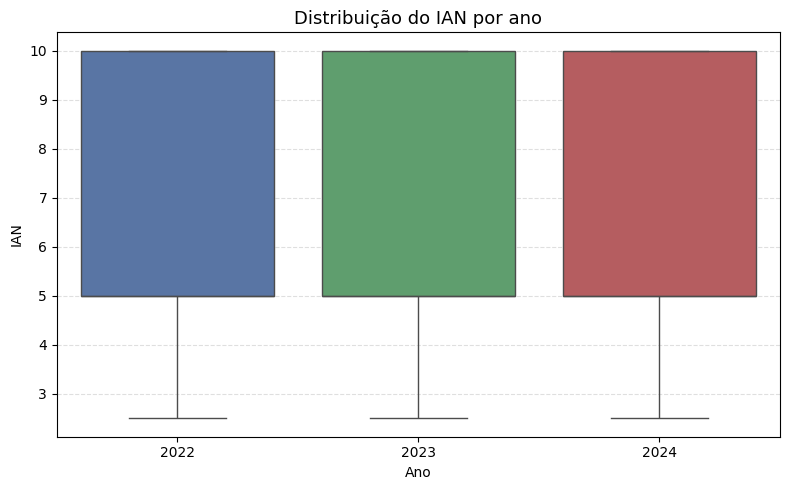

In [63]:
df_tratado["ano"] = df_tratado["ano"].astype(str)

plt.figure(figsize=(8,5))
sns.boxplot(data=df_tratado, x="ano", y="IAN", palette=["#4C72B0", "#55A868", "#C44E52"])

plt.title("Distribuição do IAN por ano", fontsize=13)
plt.xlabel("Ano")
plt.ylabel("IAN")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig('distribuicao_ian.png', dpi=300, bbox_inches='tight')
plt.show()

In [64]:
#transformar os anos em colunas
df_pivot = df_tratado.pivot(
    index='Nome',
    columns='ano',
    values='IAN'
)
#Calcular os deltas
df_pivot['delta_ian_22_23'] = df_pivot['2023'] - df_pivot['2022']
df_pivot['delta_ian_23_24'] = df_pivot['2024'] - df_pivot['2023']

#Descrever as variações
df_pivot[['delta_ian_22_23','delta_ian_23_24']].describe()

ano,delta_ian_22_23,delta_ian_23_24
count,570.000000,678.000000
mean,0.271930,0.571534
std,2.569885,2.963909
min,-5.000000,-5.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,7.500000,5.000000


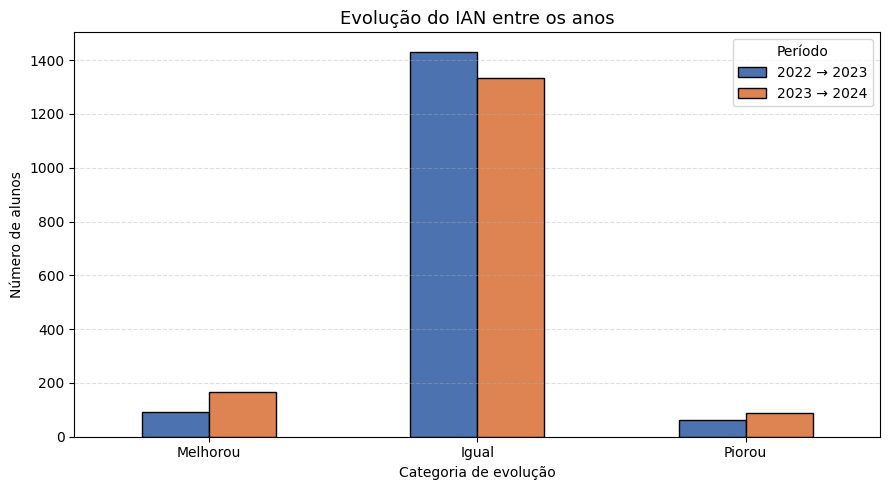

          2022 → 2023  2023 → 2024
Melhorou           93          165
Igual            1432         1334
Piorou             61           87


In [65]:
df_pivot['evolucao_22_23'] = df_pivot['delta_ian_22_23'].apply(
    lambda x: 'Melhorou' if x > 0 else ('Piorou' if x < 0 else 'Igual')
)

df_pivot['evolucao_23_24'] = df_pivot['delta_ian_23_24'].apply(
    lambda x: 'Melhorou' if x > 0 else ('Piorou' if x < 0 else 'Igual')
)

# =========================
# Contar alunos por categoria
# =========================

ordem = ['Melhorou', 'Igual', 'Piorou']

contagem_22_23 = (
    df_pivot['evolucao_22_23']
    .value_counts()
    .reindex(ordem, fill_value=0)
)

contagem_23_24 = (
    df_pivot['evolucao_23_24']
    .value_counts()
    .reindex(ordem, fill_value=0)
)

# =========================
# Criar dataframe para o gráfico
# =========================

df_evolucao = pd.DataFrame({
    '2022 → 2023': contagem_22_23,
    '2023 → 2024': contagem_23_24
})

# =========================
# Plotar gráfico
# =========================

ax = df_evolucao.plot(
    kind='bar',
    figsize=(9, 5),
    color=['#4C72B0', '#DD8452'],
    edgecolor='black'
)

plt.title('Evolução do IAN entre os anos', fontsize=13)
plt.xlabel('Categoria de evolução')
plt.ylabel('Número de alunos')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Período')

plt.tight_layout()
plt.savefig('evolucao_ian_categorias.png', dpi=300, bbox_inches='tight')
plt.show()

# =========================
# 8. Mostrar tabela de contagem
# =========================

print(df_evolucao)

O **Indicador de Adequação de Nível (IAN)** é uma métrica utilizada para avaliar se o estudante se encontra no nível educacional adequado para sua idade. Esse indicador é calculado a partir da diferença entre a **fase educacional efetiva do aluno** e a **fase ideal esperada para sua faixa etária**. De acordo com a metodologia do indicador, valores de **IAN iguais a 10 indicam alunos em fase adequada**, valores próximos de **5 representam defasagem moderada**, e valores em torno de **2,5 indicam defasagem severa**.

A análise da distribuição do IAN ao longo dos anos de **2022, 2023 e 2024** mostra que a maior parte dos alunos permanece concentrada entre os níveis **5 e 10**, indicando predominância de estudantes em **defasagem moderada ou já em fase adequada**. Os boxplots apresentam distribuições bastante semelhantes entre os anos, sugerindo uma **relativa estabilidade no perfil geral de adequação educacional** da população analisada. Observa-se também a presença de um grupo menor de alunos com valores próximos de **2,5**, caracterizando casos de **defasagem severa**, que demandam maior atenção e intervenções pedagógicas específicas.

Ao analisar a **evolução do IAN entre os anos**, observa-se que a maioria dos alunos permanece no mesmo nível de adequação de um ano para o outro. Entre **2022 e 2023**, aproximadamente **1.432 alunos mantiveram o mesmo nível**, enquanto **93 apresentaram melhora** e **61 apresentaram piora**. Já no período de **2023 para 2024**, houve um aumento no número de alunos que apresentaram melhora (**165 alunos**), além de **1.334 que permaneceram estáveis** e **87 que apresentaram redução no indicador**.

Esses resultados indicam que, embora a maior parte dos estudantes apresente **estabilidade no indicador de adequação**, há sinais de **progressão educacional ao longo do tempo**, especialmente no período mais recente. O aumento no número de alunos que melhoraram seu nível entre **2023 e 2024** sugere possíveis avanços nas estratégias educacionais ou nos mecanismos de acompanhamento pedagógico.

De forma geral, os resultados apontam para um cenário de **predominância de estabilidade com tendência gradual de melhora**, ao mesmo tempo em que evidenciam a existência de um grupo menor de alunos que permanece em situação de maior defasagem. Esse panorama reforça a importância de **políticas educacionais e intervenções pedagógicas direcionadas**, capazes de apoiar os estudantes com maior dificuldade e promover avanços mais consistentes na adequação do nível educacional ao longo do tempo.


## **2. Desempenho acadêmico (IDA): O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?**


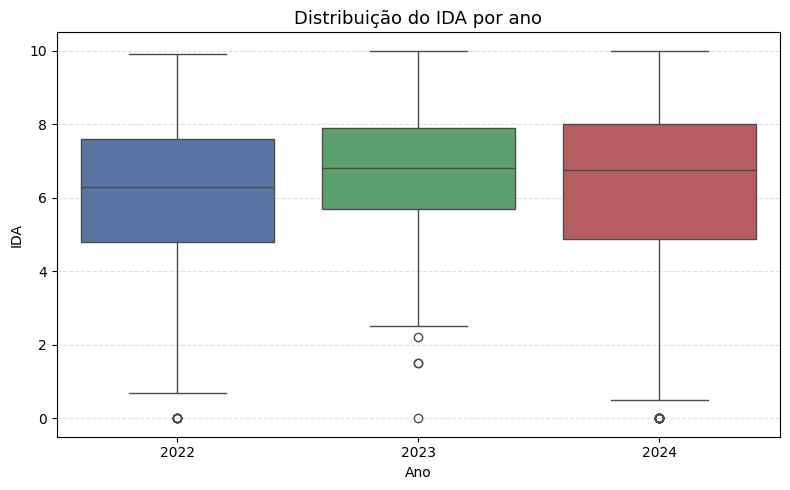

In [66]:
df_tratado['ano'] = df_tratado['ano'].astype(str)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_tratado,
    x='ano',
    y='IDA',
    palette=["#4C72B0","#55A868","#C44E52"]
)

plt.title("Distribuição do IDA por ano", fontsize=13)
plt.xlabel("Ano")
plt.ylabel("IDA")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig('Distribuição_ida.png', dpi=300, bbox_inches='tight')
plt.show()

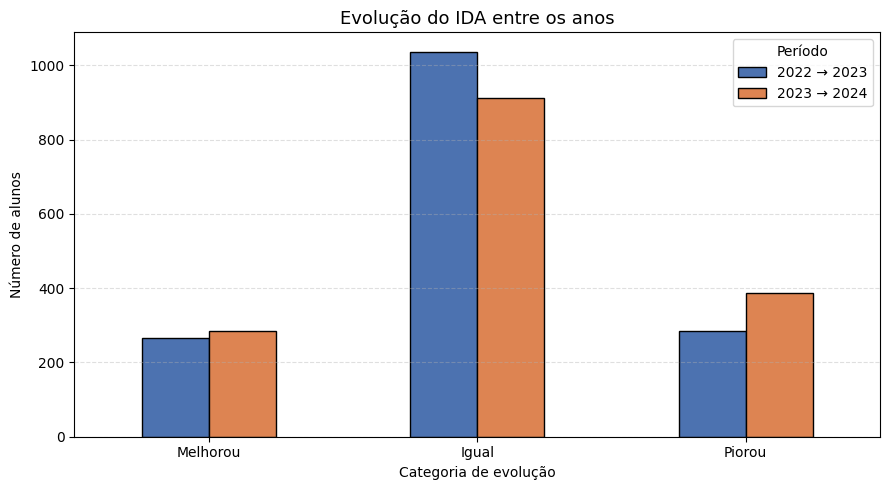

          2022 → 2023  2023 → 2024
Melhorou          265          286
Igual            1037          913
Piorou            284          387


In [67]:
# ==========================================
# Pivotar o IDA por aluno e ano
# ==========================================
df_ida = df_tratado.pivot(
    index='Nome',
    columns='ano',
    values='IDA'
)

# ==========================================
# Calcular os deltas do IDA
# ==========================================
df_ida['delta_ida_22_23'] = df_ida['2023'] - df_ida['2022']
df_ida['delta_ida_23_24'] = df_ida['2024'] - df_ida['2023']

# ==========================================
# Classificar evolução
# ==========================================
df_ida['evolucao_ida_22_23'] = df_ida['delta_ida_22_23'].apply(
    lambda x: 'Melhorou' if x > 0 else ('Piorou' if x < 0 else 'Igual')
)

df_ida['evolucao_ida_23_24'] = df_ida['delta_ida_23_24'].apply(
    lambda x: 'Melhorou' if x > 0 else ('Piorou' if x < 0 else 'Igual')
)

# ==========================================
# Contar alunos por categoria
# ==========================================
ordem = ['Melhorou', 'Igual', 'Piorou']

contagem_ida_22_23 = (
    df_ida['evolucao_ida_22_23']
    .value_counts()
    .reindex(ordem, fill_value=0)
)

contagem_ida_23_24 = (
    df_ida['evolucao_ida_23_24']
    .value_counts()
    .reindex(ordem, fill_value=0)
)

# ==========================================
# Criar dataframe para o gráfico
# ==========================================
df_evolucao_ida = pd.DataFrame({
    '2022 → 2023': contagem_ida_22_23,
    '2023 → 2024': contagem_ida_23_24
})

# ==========================================
# Plotar gráfico
# ==========================================
ax = df_evolucao_ida.plot(
    kind='bar',
    figsize=(9, 5),
    color=['#4C72B0', '#DD8452'],
    edgecolor='black'
)

plt.title('Evolução do IDA entre os anos', fontsize=13)
plt.xlabel('Categoria de evolução')
plt.ylabel('Número de alunos')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Período')

plt.tight_layout()
plt.savefig('evolucao_ida_categorias.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# Mostrar tabela de contagem
# ==========================================
print(df_evolucao_ida)

A análise da distribuição do IDA nos anos de **2022, 2023 e 2024**, apresentada no boxplot, mostra que o desempenho médio dos estudantes permanece concentrado em um patamar intermediário, com medianas próximas entre os anos e valores centrais aproximadamente entre **5 e 8 pontos**. Observa-se uma leve melhora do desempenho entre **2022 e 2023**, refletida em uma mediana um pouco mais elevada em 2023. Entretanto, em **2024** há um aumento da dispersão dos resultados e maior presença de valores mais baixos, indicando que parte dos alunos apresentou redução no desempenho acadêmico.

A análise da evolução individual do IDA reforça esse comportamento. Entre **2022 e 2023**, **265 alunos apresentaram melhora**, **1037 permaneceram estáveis** e **284 tiveram piora** no desempenho. Já no período de **2023 para 2024**, embora **286 alunos tenham melhorado**, observa-se aumento no número de alunos que pioraram (**387 casos**), enquanto **913 permaneceram no mesmo nível**. Esses resultados indicam que a maioria dos estudantes mantém desempenho relativamente estável ao longo do tempo, porém há um **crescimento recente no número de alunos com queda no desempenho acadêmico**.

De forma geral, os gráficos sugerem que o **IDA não apresenta tendência consistente de melhora ao longo dos anos**. Após um leve avanço entre 2022 e 2023, observa-se um cenário de **estagnação com sinais de deterioração em 2024**, caracterizado pelo aumento de alunos com queda no desempenho e maior dispersão nos resultados. Esse padrão pode indicar dificuldades na consolidação da aprendizagem e aponta para a necessidade de **estratégias pedagógicas voltadas ao fortalecimento do desempenho acadêmico**, especialmente para os alunos que apresentam queda ou instabilidade no indicador.

## **3. Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?**

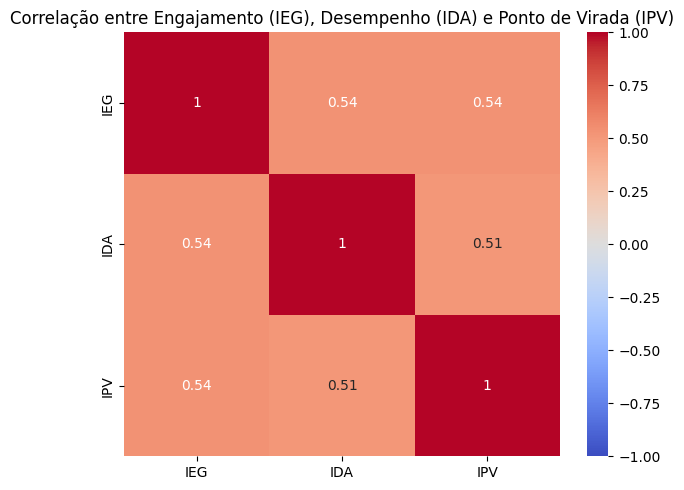

In [68]:
# ==========================================
# Correlação entre IEG, IDA e IPV por ano
# ==========================================
df_corr = df[['IEG','IDA','IPV']].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    df_corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0
)

plt.title('Correlação entre Engajamento (IEG), Desempenho (IDA) e Ponto de Virada (IPV)')

plt.tight_layout()

plt.savefig("heatmap_correlacao_engajamento.png", dpi=300, bbox_inches="tight")

plt.show()

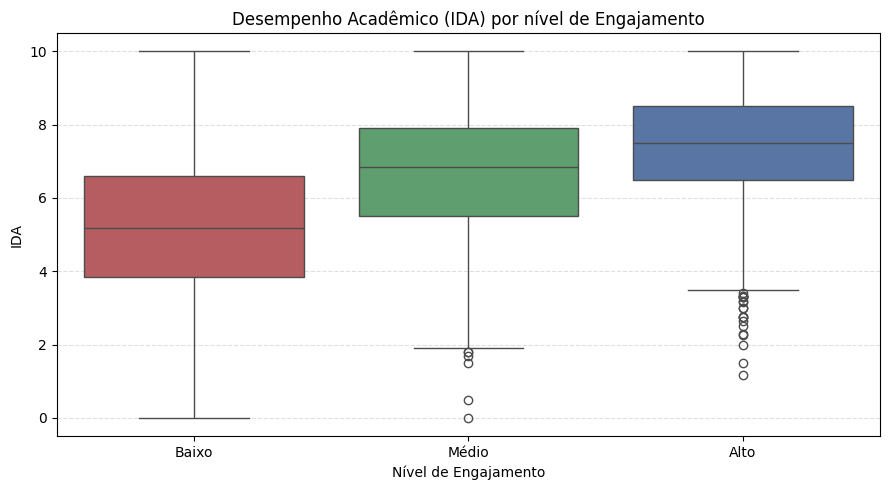

In [69]:
# ==========================================
# Boxplot do IDA por faixa de IEG
# ==========================================
df_plot = df_tratado.copy()

df_plot['ieg_faixa'] = pd.qcut(
    df_plot['IEG'],
    3,
    labels=['Baixo','Médio','Alto']
)

plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_plot,
    x='ieg_faixa',
    y='IDA',
    palette=['#C44E52','#55A868','#4C72B0']
)

plt.title('Desempenho Acadêmico (IDA) por nível de Engajamento')
plt.xlabel('Nível de Engajamento')
plt.ylabel('IDA')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig("ida_por_engajamento.png", dpi=300, bbox_inches="tight")

plt.show()

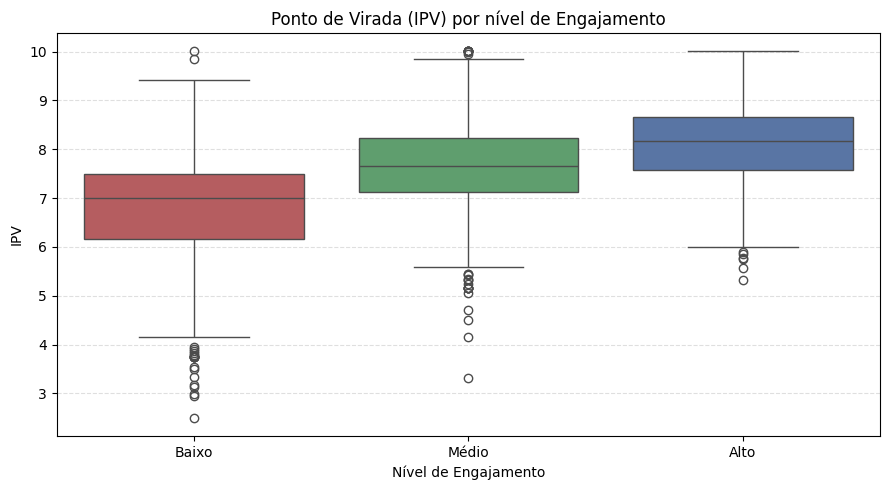

In [70]:
# ==========================================
# Boxplot do IPV por faixa de IEG
# ==========================================
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_plot,
    x='ieg_faixa',
    y='IPV',
    palette=['#C44E52','#55A868','#4C72B0']
)

plt.title('Ponto de Virada (IPV) por nível de Engajamento')
plt.xlabel('Nível de Engajamento')
plt.ylabel('IPV')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig("ipv_por_engajamento.png", dpi=300, bbox_inches="tight")

plt.show()

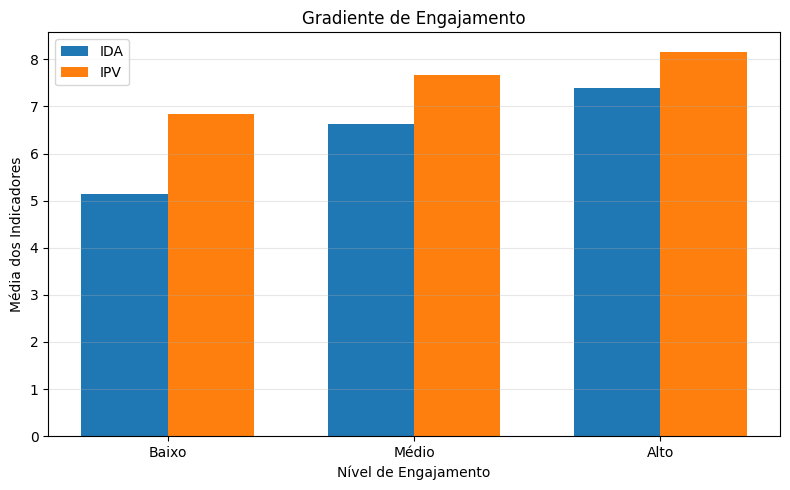

In [71]:
df_media = df_plot.groupby('ieg_faixa').agg(
    IDA_medio=('IDA','mean'),
    IPV_medio=('IPV','mean')
).reset_index()

# posições das barras
x = np.arange(len(df_media['ieg_faixa']))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    df_media['IDA_medio'],
    width,
    label='IDA'
)

plt.bar(
    x + width/2,
    df_media['IPV_medio'],
    width,
    label='IPV'
)

plt.xticks(x, df_media['ieg_faixa'])

plt.title('Gradiente de Engajamento')
plt.xlabel('Nível de Engajamento')
plt.ylabel('Média dos Indicadores')

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("gradiente_engajamento_barras.png", dpi=300, bbox_inches='tight')
plt.show()

Os resultados indicam uma **relação positiva moderada entre o nível de engajamento dos alunos nas atividades (IEG) e seus indicadores de desempenho acadêmico (IDA) e progressão educacional (IPV)**.

A matriz de correlação mostra que o engajamento apresenta correlação de aproximadamente **0,54 com o IDA e 0,54 com o IPV**, enquanto o IDA e o IPV também apresentam correlação positiva entre si (**0,51**). Esses valores sugerem que alunos mais engajados tendem, em média, a apresentar **melhores níveis de desempenho acadêmico e maior avanço educacional**.

A análise dos **boxplots por nível de engajamento** reforça essa evidência. Observa-se que os alunos classificados no grupo de **alto engajamento apresentam medianas de desempenho (IDA) mais elevadas**, enquanto os alunos com **baixo engajamento concentram os menores valores de desempenho**. Um padrão semelhante é observado no indicador de **ponto de virada (IPV)**, em que níveis mais altos de engajamento estão associados a maiores valores do indicador.

O **gráfico de gradiente de engajamento** sintetiza esse comportamento ao mostrar um aumento progressivo nas médias de IDA e IPV conforme se passa do nível de engajamento **baixo para médio e alto**. Esse padrão evidencia a existência de um **gradiente positivo**, no qual o aumento do engajamento está associado a melhorias consistentes nos indicadores educacionais.

Portanto, os resultados sugerem que **o engajamento nas atividades educacionais está associado a melhores resultados acadêmicos e maior progressão educacional**. Embora a análise não permita afirmar causalidade direta, os padrões observados indicam que **estratégias pedagógicas voltadas ao aumento do engajamento dos alunos podem contribuir para a melhoria do desempenho acadêmico e do desenvolvimento educacional**.


## **4. Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?**

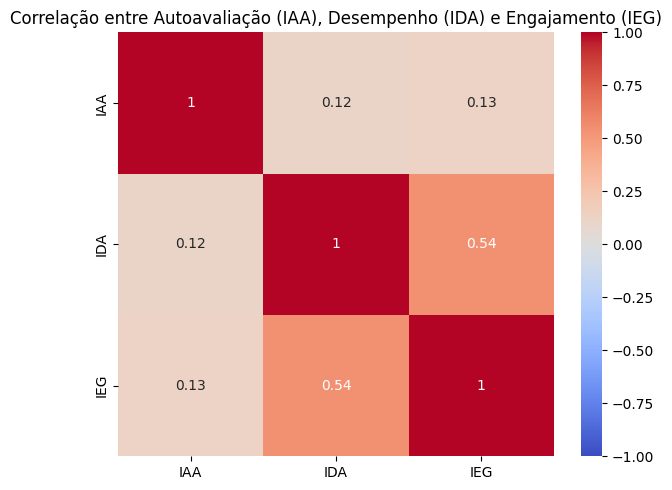

In [72]:
plt.figure(figsize=(6,5))

corr = df_tratado[['IAA','IDA','IEG']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0
)

plt.title('Correlação entre Autoavaliação (IAA), Desempenho (IDA) e Engajamento (IEG)')

plt.tight_layout()

plt.savefig("correlacao_autoavaliacao.png", dpi=300, bbox_inches="tight")

plt.show()

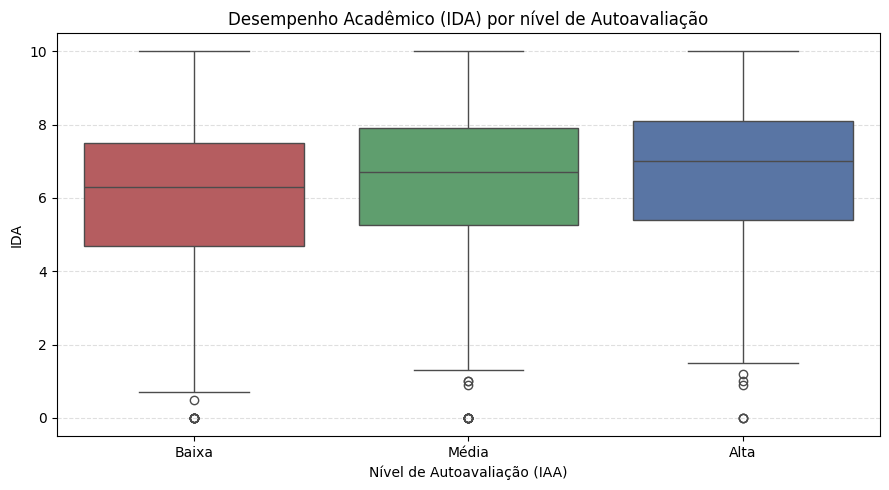

In [73]:
df_plot['iaa_faixa'] = pd.qcut(
    df_plot['IAA'],
    3,
    labels=['Baixa','Média','Alta']
)

plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_plot,
    x='iaa_faixa',
    y='IDA',
    palette=['#C44E52','#55A868','#4C72B0']
)

plt.title('Desempenho Acadêmico (IDA) por nível de Autoavaliação')
plt.xlabel('Nível de Autoavaliação (IAA)')
plt.ylabel('IDA')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig("ida_por_autoavaliacao.png", dpi=300, bbox_inches="tight")

plt.show()

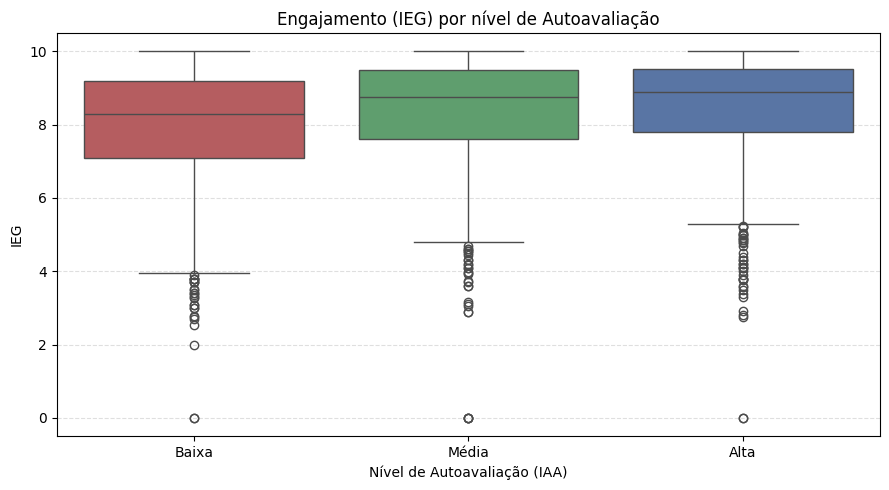

In [74]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_plot,
    x='iaa_faixa',
    y='IEG',
    palette=['#C44E52','#55A868','#4C72B0']
)

plt.title('Engajamento (IEG) por nível de Autoavaliação')
plt.xlabel('Nível de Autoavaliação (IAA)')
plt.ylabel('IEG')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig("ieg_por_autoavaliacao.png", dpi=300, bbox_inches="tight")

plt.show()

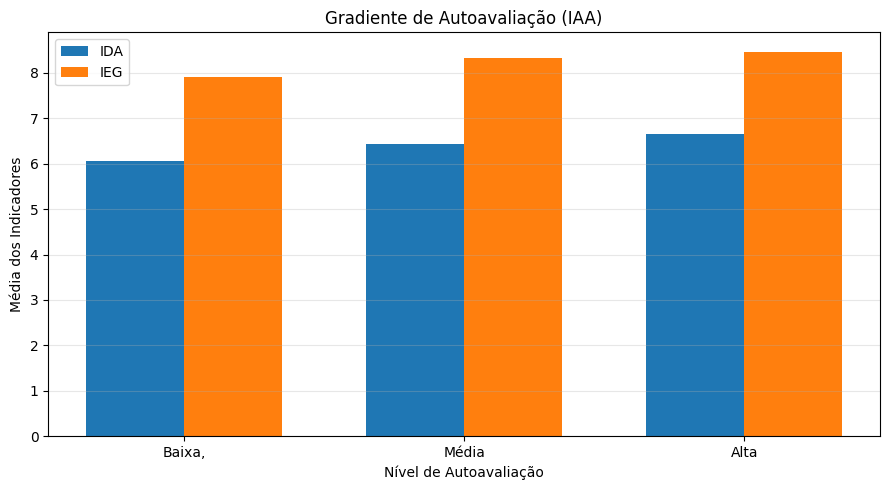

In [75]:
df_plot=df_plot.dropna(subset=['IAA','IDA','IEG'])

df_plot['iaa_faixa'] = pd.qcut(
    df_plot['IAA'],
    3,
    labels=['Baixa,','Média','Alta']
)

df_media=df_plot.groupby('iaa_faixa').agg(
    IDA_medio=('IDA','mean'),
    IEG_medio=('IEG','mean'),
    alunos=('IAA','count')
).reset_index()


# posições das barras
x = np.arange(len(df_media['iaa_faixa']))
width = 0.35

plt.figure(figsize=(9,5))

# barras de IDA
plt.bar(
    x - width/2,
    df_media['IDA_medio'],
    width,
    label='IDA'
)

# barras de IEG
plt.bar(
    x + width/2,
    df_media['IEG_medio'],
    width,
    label='IEG'
)

# rótulos do eixo x
plt.xticks(x, df_media['iaa_faixa'])

plt.title('Gradiente de Autoavaliação (IAA)')
plt.xlabel('Nível de Autoavaliação')
plt.ylabel('Média dos Indicadores')

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("gradiente_autoavaliacao_barras.png", dpi=300, bbox_inches='tight')
plt.show()

A análise da relação entre **autoavaliação dos alunos (IAA), desempenho acadêmico (IDA) e engajamento nas atividades (IEG)** indica que a percepção dos estudantes sobre si mesmos apresenta **baixa coerência com seus resultados reais e seu nível de participação nas atividades educacionais**.

A matriz de correlação mostra que a associação entre autoavaliação e os demais indicadores é **fraca**, com coeficientes de aproximadamente **0,12 entre IAA e IDA** e **0,13 entre IAA e IEG**. Em contraste, observa-se uma **relação moderada entre desempenho acadêmico e engajamento (0,54)**, indicando que alunos mais engajados tendem a apresentar melhores resultados acadêmicos.

A análise dos **boxplots** reforça essa interpretação. Embora exista uma leve tendência de aumento nas medianas de desempenho e engajamento entre alunos com níveis mais elevados de autoavaliação, as distribuições dos grupos apresentam **grande sobreposição**, indicando que estudantes com percepções diferentes sobre seu próprio desempenho podem apresentar resultados semelhantes.

O **gráfico de gradiente de autoavaliação** também evidencia esse comportamento. Observa-se um crescimento discreto nas médias de desempenho acadêmico (IDA) e engajamento (IEG) conforme aumenta o nível de autoavaliação, porém essa variação é relativamente pequena, sugerindo que a percepção dos alunos sobre si mesmos possui **capacidade limitada de explicar as diferenças observadas nos indicadores educacionais**.

Dessa forma, os resultados indicam que **a autoavaliação dos estudantes não se mostra um indicador confiável do desempenho acadêmico ou do nível de engajamento nas atividades**. Em comparação, o engajamento apresenta uma relação mais consistente com o desempenho, sugerindo que o comportamento de participação nas atividades educacionais constitui um fator mais relevante para explicar os resultados acadêmicos dos alunos.


## **5. Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?**

In [76]:
sns.set(style="whitegrid")

# ======================================
# 1. Preparar base
# ======================================

df_p5 = df_tratado[['Nome','ano','IPS','IDA','IEG']].copy()

df_p5['ano'] = df_p5['ano'].astype(int)

df_p5 = df_p5.sort_values(['Nome','ano'])

# ======================================
# 2. Calcular mudança para o ano seguinte
# ======================================

df_p5['delta_ida_next'] = df_p5.groupby('Nome')['IDA'].shift(-1) - df_p5['IDA']
df_p5['delta_ieg_next'] = df_p5.groupby('Nome')['IEG'].shift(-1) - df_p5['IEG']

df_p5['queda_ida'] = (df_p5['delta_ida_next'] < 0).astype(int)
df_p5['queda_ieg'] = (df_p5['delta_ieg_next'] < 0).astype(int)

df_valid = df_p5.dropna(subset=['IPS','delta_ida_next','delta_ieg_next']).copy()

# ======================================
# 3. Criar faixas de IPS
# ======================================

df_valid['ips_faixa'] = (
    df_valid.groupby('ano')['IPS']
    .transform(lambda x: pd.qcut(x,3,labels=['Baixo','Médio','Alto'],duplicates='drop'))
)

# ======================================
# 4. Criar tabela de probabilidade
# ======================================

prob_queda = (
    df_valid.groupby(['ano','ips_faixa'])
    .agg(
        prob_queda_ida=('queda_ida','mean'),
        prob_queda_ieg=('queda_ieg','mean'),
        media_delta_ida=('delta_ida_next','mean'),
        media_delta_ieg=('delta_ieg_next','mean')
    )
    .reset_index()
)

prob_queda['prob_queda_ida'] = prob_queda['prob_queda_ida']*100
prob_queda['prob_queda_ieg'] = prob_queda['prob_queda_ieg']*100


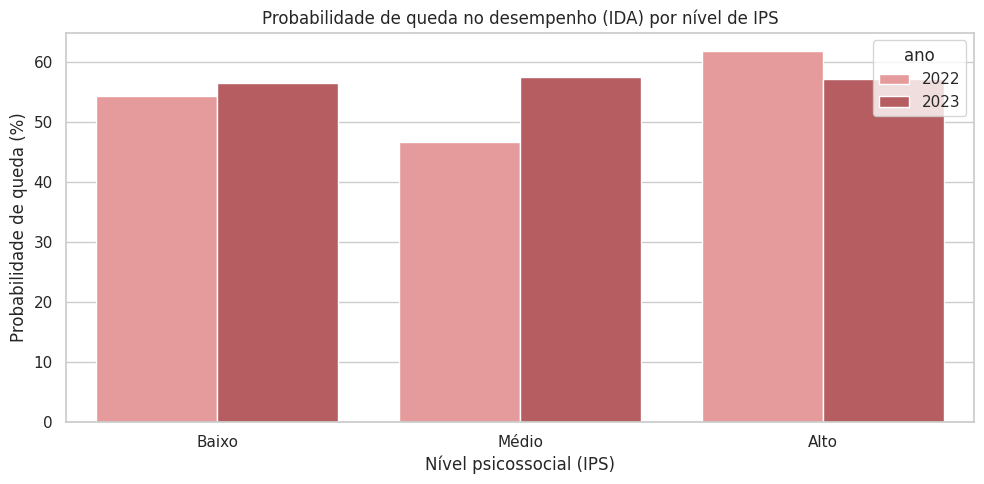

In [77]:
# ======================================
# 5. Gráfico 1
# Probabilidade de queda IDA
# ======================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=prob_queda,
    x='ips_faixa',
    y='prob_queda_ida',
    hue='ano',
    palette=['#F28E8E','#C44E52']
)

plt.title('Probabilidade de queda no desempenho (IDA) por nível de IPS')
plt.xlabel('Nível psicossocial (IPS)')
plt.ylabel('Probabilidade de queda (%)')

plt.tight_layout()

plt.savefig("p5_prob_queda_ida.png",dpi=300,bbox_inches='tight')

plt.show()


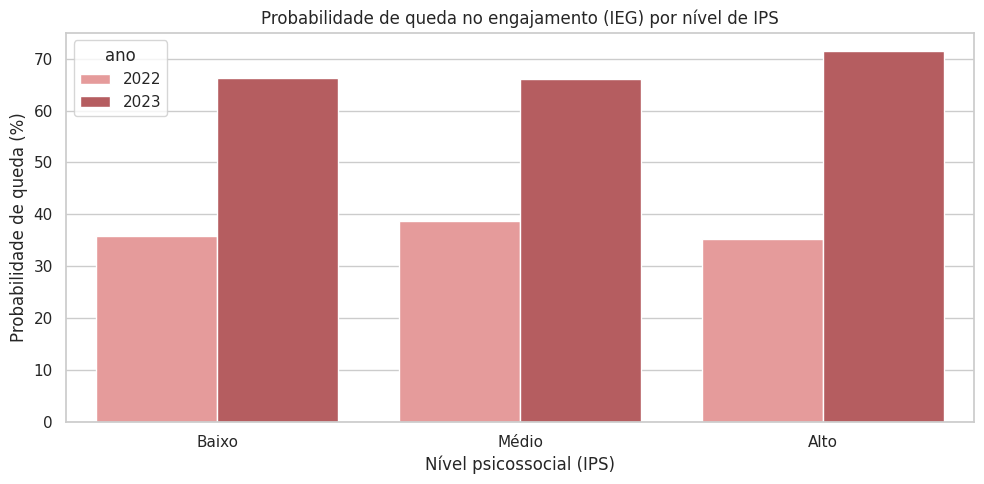

In [78]:
# ======================================
# 6. Gráfico 2
# Probabilidade de queda IEG
# ======================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=prob_queda,
    x='ips_faixa',
    y='prob_queda_ieg',
    hue='ano',
    palette=['#F28E8E','#C44E52']
)
plt.title('Probabilidade de queda no engajamento (IEG) por nível de IPS')
plt.xlabel('Nível psicossocial (IPS)')
plt.ylabel('Probabilidade de queda (%)')

plt.tight_layout()

plt.savefig("p5_prob_queda_ieg.png",dpi=300,bbox_inches='tight')

plt.show()

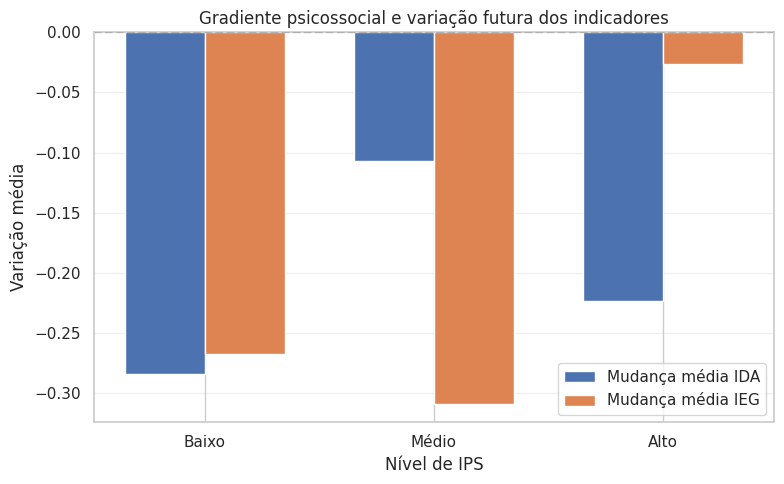

In [79]:
grad = (
    prob_queda.groupby('ips_faixa')[['media_delta_ida','media_delta_ieg']]
    .mean()
    .reset_index()
)


# posições das barras
x = np.arange(len(grad['ips_faixa']))
width = 0.35

plt.figure(figsize=(8,5))

# barras da mudança em IDA
plt.bar(
    x - width/2,
    grad['media_delta_ida'],
    width,
    label='Mudança média IDA'
)

# barras da mudança em IEG
plt.bar(
    x + width/2,
    grad['media_delta_ieg'],
    width,
    label='Mudança média IEG'
)

# linha zero
plt.axhline(0, linestyle='--', color='black')

# rótulos
plt.xticks(x, grad['ips_faixa'])

plt.title('Gradiente psicossocial e variação futura dos indicadores')
plt.xlabel('Nível de IPS')
plt.ylabel('Variação média')

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("p5_gradiente_psicossocial_barras.png", dpi=300, bbox_inches='tight')
plt.show()

A análise dos indicadores psicossociais (IPS) em relação às variações futuras no desempenho acadêmico (IDA) e no engajamento escolar (IEG) sugere que a relação entre fatores psicossociais e os indicadores educacionais não apresenta um padrão linear claro de proteção ou risco.

Os gráficos de probabilidade de queda mostram que a chance de redução no desempenho acadêmico permanece relativamente elevada em todos os níveis de IPS. Em 2022, por exemplo, a probabilidade de queda no desempenho varia entre aproximadamente **46% e 62%**, enquanto em 2023 os valores se concentram entre **56% e 57%**, indicando diferenças relativamente pequenas entre os níveis psicossociais.

Da mesma forma, a probabilidade de queda no engajamento apresenta níveis elevados em todos os grupos em 2023, alcançando valores próximos de **66% a 71%**, o que sugere que a redução no engajamento não está fortemente associada apenas ao nível psicossocial observado no período anterior.

A análise do gradiente psicossocial reforça essa interpretação. A variação média futura do desempenho acadêmico (IDA) apresenta tendência negativa em todos os níveis de IPS, indicando que, em média, houve redução no desempenho no período seguinte independentemente do nível psicossocial inicial. No caso do engajamento (IEG), observa-se uma leve melhora média apenas entre alunos com níveis mais altos de IPS, enquanto os demais grupos apresentam variações negativas ou próximas de zero.

Em conjunto, esses resultados indicam que **os indicadores psicossociais analisados não apresentam evidências claras de que, isoladamente, antecedam ou expliquem quedas futuras no desempenho acadêmico ou no engajamento escolar**. Embora possam estar relacionados a variações nos indicadores educacionais, os dados sugerem que a dinâmica do desempenho e do engajamento depende provavelmente da interação entre múltiplos fatores, e não apenas do nível psicossocial observado em um único período.

## **6. Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?**

In [80]:
sns.set(style="whitegrid")


df_p6 = df_tratado[['Nome', 'ano', 'IAN', 'IPP']].copy()

# garantir tipo do ano
df_p6['ano'] = df_p6['ano'].astype(int)

# remover faltantes
df_p6 = df_p6.dropna(subset=['IAN', 'IPP']).copy()

# ======================================
# 2. Criar faixas de IAN por ano
#    usando rank para quebrar empates
# ======================================
df_p6['ian_faixa'] = (
    df_p6.groupby('ano')['IAN']
    .transform(lambda s: pd.qcut(
        s.rank(method='first'),
        3,
        labels=['Baixo', 'Médio', 'Alto']
    ))
)

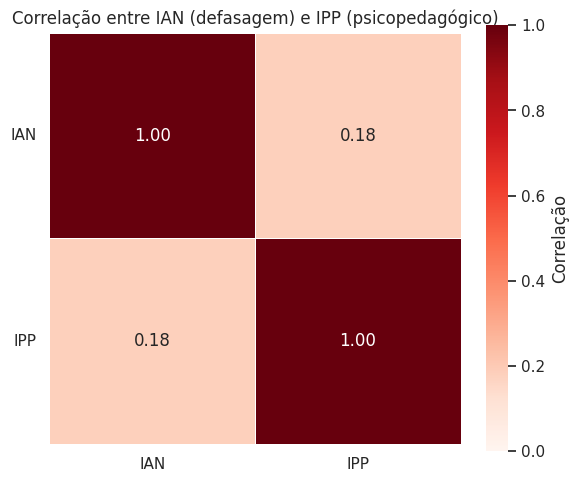

In [81]:
# calcular correlação
corr = df_p6[['IAN', 'IPP']].corr()

# estilo do gráfico
sns.set(style="whitegrid")

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='Reds',
    vmin=0, vmax=1,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlação'}
)

plt.title("Correlação entre IAN (defasagem) e IPP (psicopedagógico)")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig("p6_correlacao_ian_ipp.png", dpi=300, bbox_inches="tight")

plt.show()

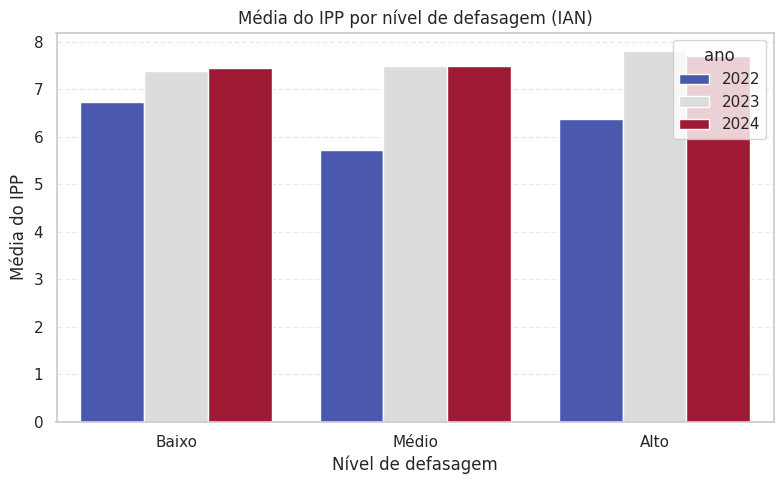

In [82]:
resumo_p6 = (
    df_p6.groupby(['ano', 'ian_faixa'], observed=True)['IPP']
    .agg(
        media_ipp='mean',
        mediana_ipp='median',
        alunos='count'
    )
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=resumo_p6,
    x='ian_faixa',
    y='media_ipp',
    hue='ano',
    palette='coolwarm'
)

plt.title("Média do IPP por nível de defasagem (IAN)")
plt.xlabel("Nível de defasagem")
plt.ylabel("Média do IPP")

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("media_ian_ipp.png", dpi=300, bbox_inches="tight")

plt.show()

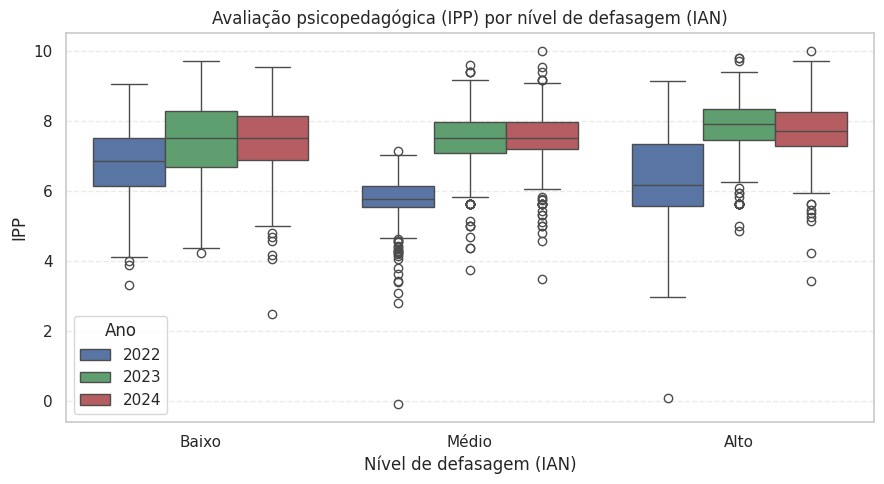

In [83]:
# ======================================
# Boxplot principal
# ======================================
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_p6,
    x='ian_faixa',
    y='IPP',
    hue='ano',
    palette=['#4C72B0', '#55A868', '#C44E52']
)

plt.title('Avaliação psicopedagógica (IPP) por nível de defasagem (IAN)')
plt.xlabel('Nível de defasagem (IAN)')
plt.ylabel('IPP')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Ano')

plt.tight_layout()
plt.savefig("p6_boxplot_ipp_por_ian.png", dpi=300, bbox_inches='tight')
plt.show()

A análise da relação entre o indicador de defasagem acadêmica (IAN) e as avaliações psicopedagógicas (IPP) teve como objetivo verificar se as avaliações psicopedagógicas confirmam ou contradizem os níveis de defasagem identificados academicamente. A correlação entre os dois indicadores apresentou valor aproximado de **0,18**, indicando uma associação positiva, porém de baixa magnitude. Esse resultado sugere que, embora exista alguma relação entre os dois indicadores, ela não é suficientemente forte para indicar uma correspondência direta entre a defasagem acadêmica identificada e a avaliação psicopedagógica dos estudantes.

A análise das médias de IPP por nível de defasagem mostra que, nos anos de **2023 e 2024**, observa-se uma tendência de aumento do IPP conforme aumenta o nível de defasagem identificado pelo IAN. Nesse período, estudantes classificados em níveis mais elevados de defasagem apresentam, em média, valores de IPP ligeiramente maiores, sugerindo certa coerência entre os dois indicadores. No entanto, esse padrão não se manifesta de forma completamente consistente em todos os anos analisados, como observado em **2022**, onde a distribuição das médias não apresenta um gradiente claro entre os níveis de defasagem.

A análise das distribuições por meio do **boxplot** reforça essa interpretação. Embora seja possível observar que os grupos com maior defasagem tendem a apresentar valores médios de IPP ligeiramente superiores, há uma **considerável sobreposição entre as distribuições** dos diferentes níveis de IAN. Isso indica que muitos estudantes classificados em diferentes níveis de defasagem apresentam avaliações psicopedagógicas semelhantes, o que limita a capacidade do IPP de distinguir claramente os níveis de defasagem identificados pelo indicador acadêmico.

Dessa forma, os resultados sugerem que as avaliações psicopedagógicas **tendem a acompanhar parcialmente** os níveis de defasagem identificados pelo IAN, especialmente nos anos mais recentes analisados. Contudo, a baixa intensidade da correlação e a sobreposição entre os grupos indicam que o IPP **não confirma de forma plena ou consistente** a defasagem acadêmica apontada pelo IAN. Assim, o IPP parece atuar mais como um **indicador complementar**, contribuindo para a compreensão das dificuldades educacionais dos estudantes, mas não como uma validação direta ou exclusiva da defasagem acadêmica identificada.


## **7. Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?**

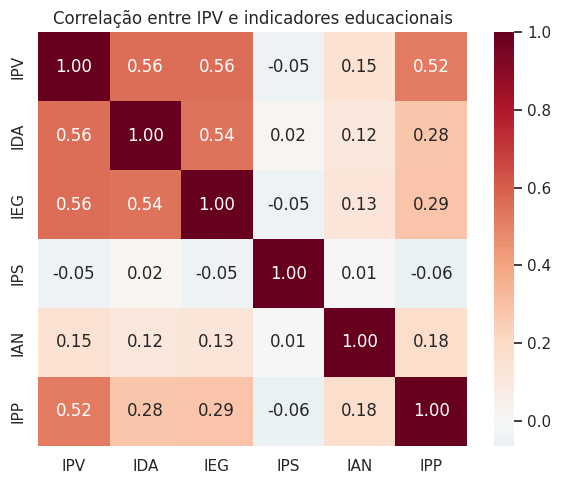

In [84]:
df_p7 = df_tratado[['Nome','ano','IPV','IDA','IEG','IPS','IAN', 'IPP']].copy()

df_p7 = df_p7.dropna()

corr_ipv = df_p7[['IPV','IDA','IEG','IPS','IAN','IPP']].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_ipv,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt=".2f"
)

plt.title("Correlação entre IPV e indicadores educacionais")

plt.tight_layout()
plt.savefig("p7_correlacao_ipv.png", dpi=300, bbox_inches="tight")
plt.show()

  Indicador  Influência
4       IPP    0.327474
1       IEG    0.202938
0       IDA    0.165347
3       IAN    0.005478
2       IPS   -0.011891


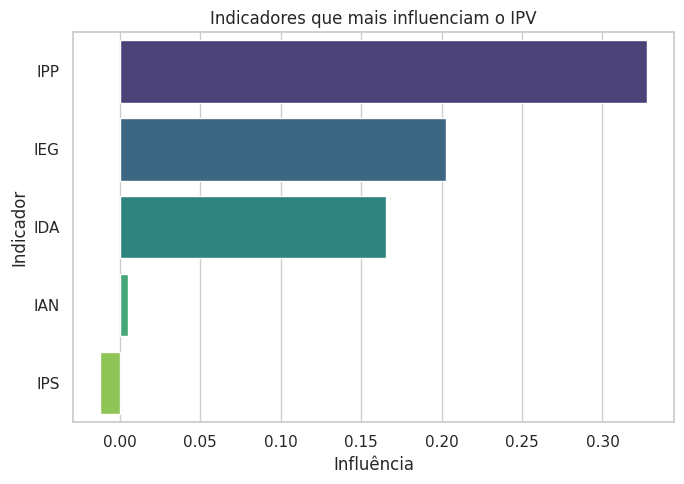

In [85]:
X = df_p7[['IDA','IEG','IPS','IAN','IPP']]
y = df_p7['IPV']

modelo = LinearRegression()
modelo.fit(X,y)

coeficientes = pd.DataFrame({
    "Indicador":X.columns,
    "Influência":modelo.coef_
})

coeficientes = coeficientes.sort_values("Influência",ascending=False)

print(coeficientes)

plt.figure(figsize=(7,5))

sns.barplot(
    data=coeficientes,
    x="Influência",
    y="Indicador",
    palette="viridis"
)

plt.title("Indicadores que mais influenciam o IPV")

plt.tight_layout()
plt.savefig("p7_importancia_ipv.png", dpi=300, bbox_inches="tight")
plt.show()

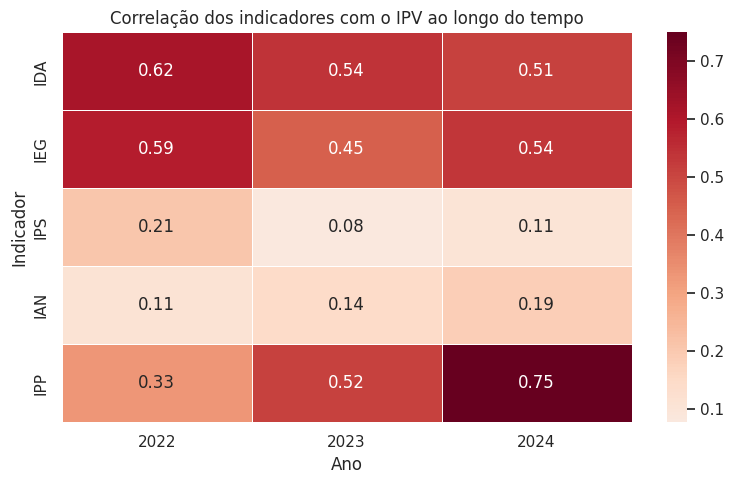

In [86]:
corr_ipv_ano = (
    df_p7
    .groupby("ano")[['IPV','IDA','IEG','IPS','IAN','IPP']]
    .corr()
    .loc[(slice(None),'IPV'),:]
)

corr_ipv_ano.index = corr_ipv_ano.index.droplevel(1)

corr_ipv_ano = corr_ipv_ano.drop(columns='IPV')
# calcular correlação por ano
corr_ipv_ano = (
    df_p7
    .groupby('ano')[['IPV','IDA','IEG','IPS','IAN','IPP']]
    .corr()
    .loc[(slice(None), 'IPV'), :]
)

# ajustar índice
corr_ipv_ano.index = corr_ipv_ano.index.droplevel(1)

# remover a autocorrelação do IPV
corr_ipv_ano = corr_ipv_ano.drop(columns='IPV')

# transpor para ficar mais visual
heat_ipv = corr_ipv_ano.T

plt.figure(figsize=(8,5))

sns.heatmap(
    heat_ipv,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlação dos indicadores com o IPV ao longo do tempo")
plt.xlabel("Ano")
plt.ylabel("Indicador")

plt.tight_layout()
plt.savefig("p7_heatmap_ipv_tempo.png", dpi=300, bbox_inches="tight")
plt.show()

A análise dos dados indica que o IPV é influenciado principalmente por indicadores acadêmicos e de desempenho, com destaque para IDA, IEG e IPP. De forma geral, esses três fatores apresentam correlações moderadas e positivas com o IPV, sugerindo que tanto a base acadêmica quanto o engajamento e a performance prática desempenham papéis relevantes na evolução do indicador. Em contrapartida, IPS e IAN apresentam correlações muito baixas, indicando pouca influência direta sobre o IPV.

Ao observar os coeficientes da regressão, percebe-se que o IPP é o indicador com maior impacto sobre o IPV, seguido por IEG e IDA. Isso sugere que, embora o desempenho acadêmico seja importante, o fator mais determinante para o aumento do IPV está relacionado à capacidade prática e produtiva dos indivíduos. O IAN apresenta uma influência pequena, enquanto o IPS praticamente não contribui para explicar a variação do IPV, podendo ser considerado secundário no contexto analisado.

A análise ao longo do tempo revela um ponto de virada importante. Nos anos iniciais, o IPV é mais fortemente associado a indicadores acadêmicos, especialmente IDA e IEG. No entanto, com o passar do tempo, observa-se uma mudança gradual em que o IPP se torna cada vez mais relevante, atingindo sua maior correlação em 2024. Esse comportamento indica que, à medida que os indivíduos avançam no processo, o desempenho prático passa a ser o principal fator de diferenciação no IPV.

Dessa forma, conclui-se que o IPV segue uma dinâmica evolutiva: inicialmente sustentado por fundamentos acadêmicos, mas progressivamente determinado pela capacidade de aplicação prática e entrega de resultados. Esse padrão sugere que estratégias educacionais ou de acompanhamento devem priorizar a construção de base no início, mas migrar o foco para o desenvolvimento de habilidades práticas ao longo do tempo, a fim de maximizar o impacto sobre o IPV.

## **Perguntas 8 a 9: Início da Modelagem para Machine Learning**

<Axes: >

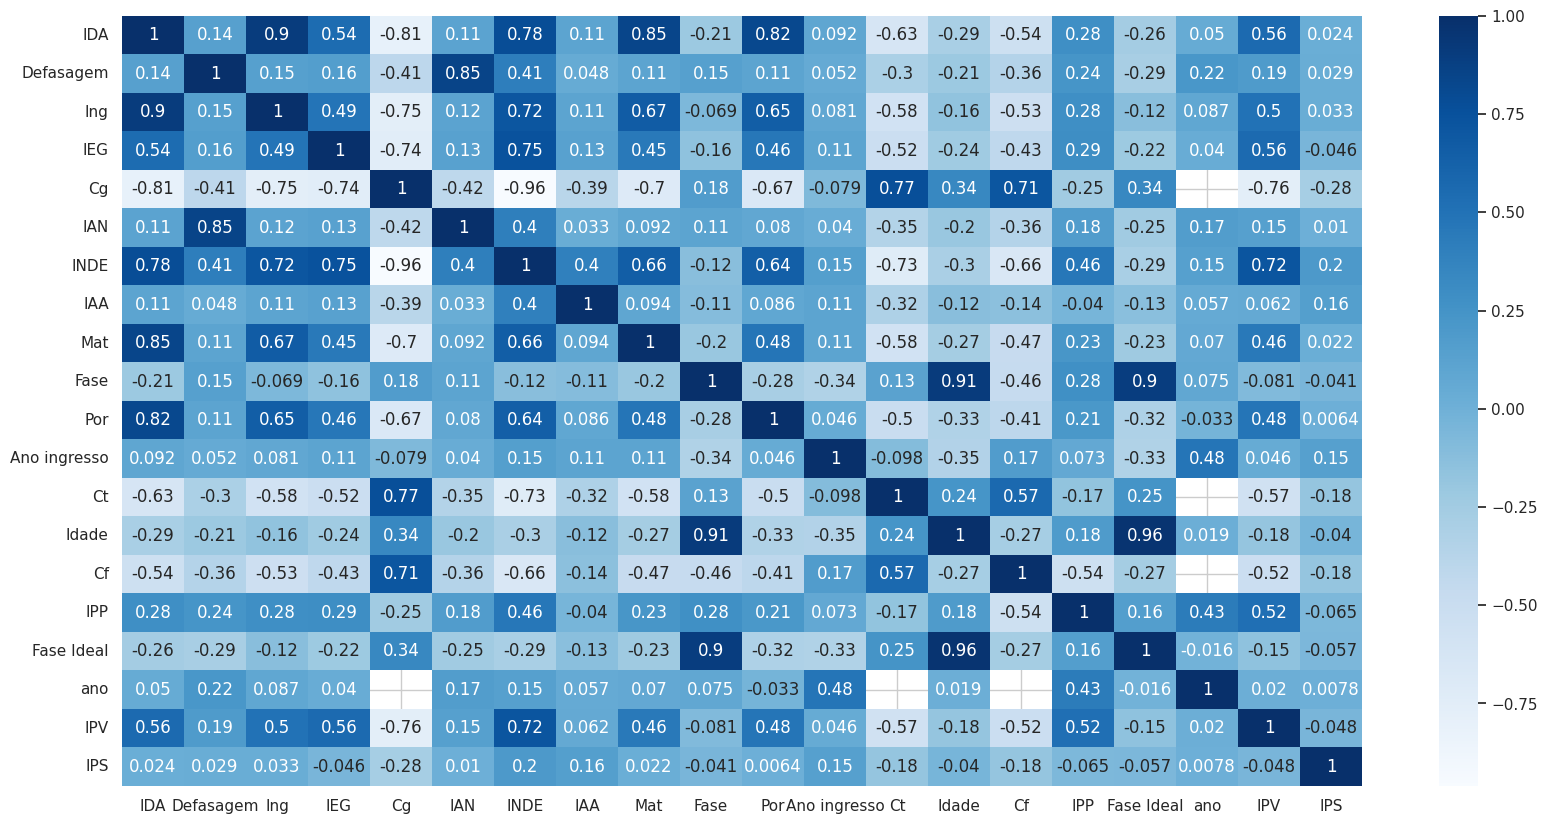

In [87]:
# Avaliando a correlação entre as variáveis numéricas

# Seleciona apenas as colunas numéricas do DataFrame
colunas_numericas = df_consolidado.select_dtypes(include=['number'])

# Calcula a matriz de correlação
corr = colunas_numericas.corr()
plt.figure(figsize = (20,10))
sns.heatmap(corr, cmap="Blues", annot=True)

## **8. Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?**

### 8.1. Modelo preditivo para INDE

In [88]:
print(df_consolidado.columns)

Index(['IDA', 'Defasagem', 'Turma', 'Pedra', 'Pedra 21', 'Ing', 'IEG', 'Cg',
       'IAN', 'INDE', 'IAA', 'Mat', 'Fase', 'Gênero', 'Por',
       'Instituição de ensino', 'Ano ingresso', 'RA', 'Ct', 'Idade', 'Cf',
       'IPP', 'Fase Ideal', 'ano', 'Nome', 'IPV', 'IPS', 'Pedra 20'],
      dtype='object')


In [89]:
# 1. Separação de Features (X) e Alvo (y)

# O RA identifica cada aluno único
groups = df_consolidado['RA']

# Adicionar colunas de interação
df_consolidado['IDA_IEG'] = df_consolidado['IDA']*df_consolidado['IEG']
df_consolidado['IDA_IPS'] = df_consolidado['IDA']*df_consolidado['IPS']
df_consolidado['IDA_IPP'] = df_consolidado['IDA']*df_consolidado['IPP']
df_consolidado['IEG_IPS'] = df_consolidado['IEG']*df_consolidado['IPS']
df_consolidado['IEG_IPP'] = df_consolidado['IEG']*df_consolidado['IPP']
df_consolidado['IPS_IPP'] = df_consolidado['IPS']*df_consolidado['IPP']

X = df_consolidado[['IDA_IEG', 'IDA_IPS', 'IDA_IPP', 'IEG_IPS', 'IEG_IPP', 'IPS_IPP']]

y = df_consolidado['INDE']

In [90]:
# 1.1. Identificar colunas numéricas e categóricas

numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(numeric_features)
print(categorical_features)

['IDA_IEG', 'IDA_IPS', 'IDA_IPP', 'IEG_IPS', 'IEG_IPP', 'IPS_IPP']
[]


In [91]:
# 2. Criação do Pipeline de Pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])

In [92]:
# 3. Divisão em Dados de Treino e Teste

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [93]:
# 4. Definição dos Modelos
modelos = {
    'Linear Regression': LinearRegression(),
    'XGBoost': XGBRegressor(random_state=42),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1)
}

In [94]:
# 5. Loop para Treinar, Avaliar e Salvar cada Modelo

# Dicionário para armazenar os pipelines treinados
trained_pipelines = {}

for name, model_instance in modelos.items():
    # Criação do Pipeline Completo (Pré-processamento + Modelo)
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('model', model_instance)])

    # Treinar o modelo
    print(f"--- Treinando o modelo: {name} ---")
    pipeline.fit(X_train, y_train)

    # Avaliação do Modelo
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"RMSE no conjunto de teste: {rmse:.4f}")
    print(f"R² no conjunto de teste:   {r2:.4f}")

    # Salvar o pipeline em memória
    trained_pipelines[name] = pipeline

--- Treinando o modelo: Linear Regression ---
RMSE no conjunto de teste: 0.3910
R² no conjunto de teste:   0.8348
--- Treinando o modelo: XGBoost ---
RMSE no conjunto de teste: 0.4229
R² no conjunto de teste:   0.8067
--- Treinando o modelo: CatBoost ---
RMSE no conjunto de teste: 0.3905
R² no conjunto de teste:   0.8352
--- Treinando o modelo: LightGBM ---
RMSE no conjunto de teste: 0.3947
R² no conjunto de teste:   0.8316


### 8.2. Verificações de overfitting

In [95]:
# 6. Verificação de Overfitting

# 6.1. Comparação Treino vs Teste
resultados_r2 = []

for name, pipeline in trained_pipelines.items():
    r2_treino = r2_score(y_train, pipeline.predict(X_train))
    r2_teste  = r2_score(y_test,  pipeline.predict(X_test))
    resultados_r2.append({
        'Modelo': name,
        'R² Treino': round(r2_treino, 4),
        'R² Teste': round(r2_teste, 4),
        'Diferença': round(r2_treino - r2_teste, 4),
        'OBS': (
                  '✅ Generaliza bem' if (r2_treino - r2_teste) < 0.05
                else '⚠️ Overfitting leve' if (r2_treino - r2_teste) < 0.10
                else '🚨 Overfitting relevante'
          )
    })

tabela_r2 = pd.DataFrame(resultados_r2)
tabela_r2

,Modelo,R² Treino,R² Teste,Diferença,OBS
0,Linear Regression,0.8375,0.8348,0.0027,✅ Generaliza bem
1,XGBoost,0.9877,0.8067,0.1810,🚨 Overfitting relevante
2,CatBoost,0.9289,0.8352,0.0937,⚠️ Overfitting leve
3,LightGBM,0.9275,0.8316,0.0959,⚠️ Overfitting leve


In [96]:
# 6.2. Cross-Validation

gkf = GroupKFold(n_splits=5)
resultados_cv = []

for name, pipeline in trained_pipelines.items():
    scores = cross_val_score(pipeline, X, y, cv=gkf, groups=groups, scoring='r2')
    def classificar_cv(r2_medio, desvio):
        if r2_medio >= 0.80 and desvio < 0.05:
            return '✅ Generaliza bem e estável'
        elif r2_medio >= 0.80 and desvio <= 0.10:
            return '⚠️ Bom desempenho, mas instável'
        elif r2_medio >= 0.80 and desvio > 0.10:
            return '🚨 Alta variância entre folds'
        elif r2_medio < 0.80 and desvio < 0.05:
            return '⚠️ Estável, mas underfitting'
        else:
            return '🚨 Fraco e instável'

    resultados_cv.append({
        'Modelo': name,
        'R² Médio CV': round(scores.mean(), 4),
        'Desvio Padrão': round(scores.std(), 4),
        'OBS': classificar_cv(scores.mean(), scores.std())
    })

tabela_cv = pd.DataFrame(resultados_cv)
tabela_cv

,Modelo,R² Médio CV,Desvio Padrão,OBS
0,Linear Regression,0.8362,0.0035,✅ Generaliza bem e estável
1,XGBoost,0.8040,0.0101,✅ Generaliza bem e estável
2,CatBoost,0.8325,0.0071,✅ Generaliza bem e estável
3,LightGBM,0.8282,0.0065,✅ Generaliza bem e estável


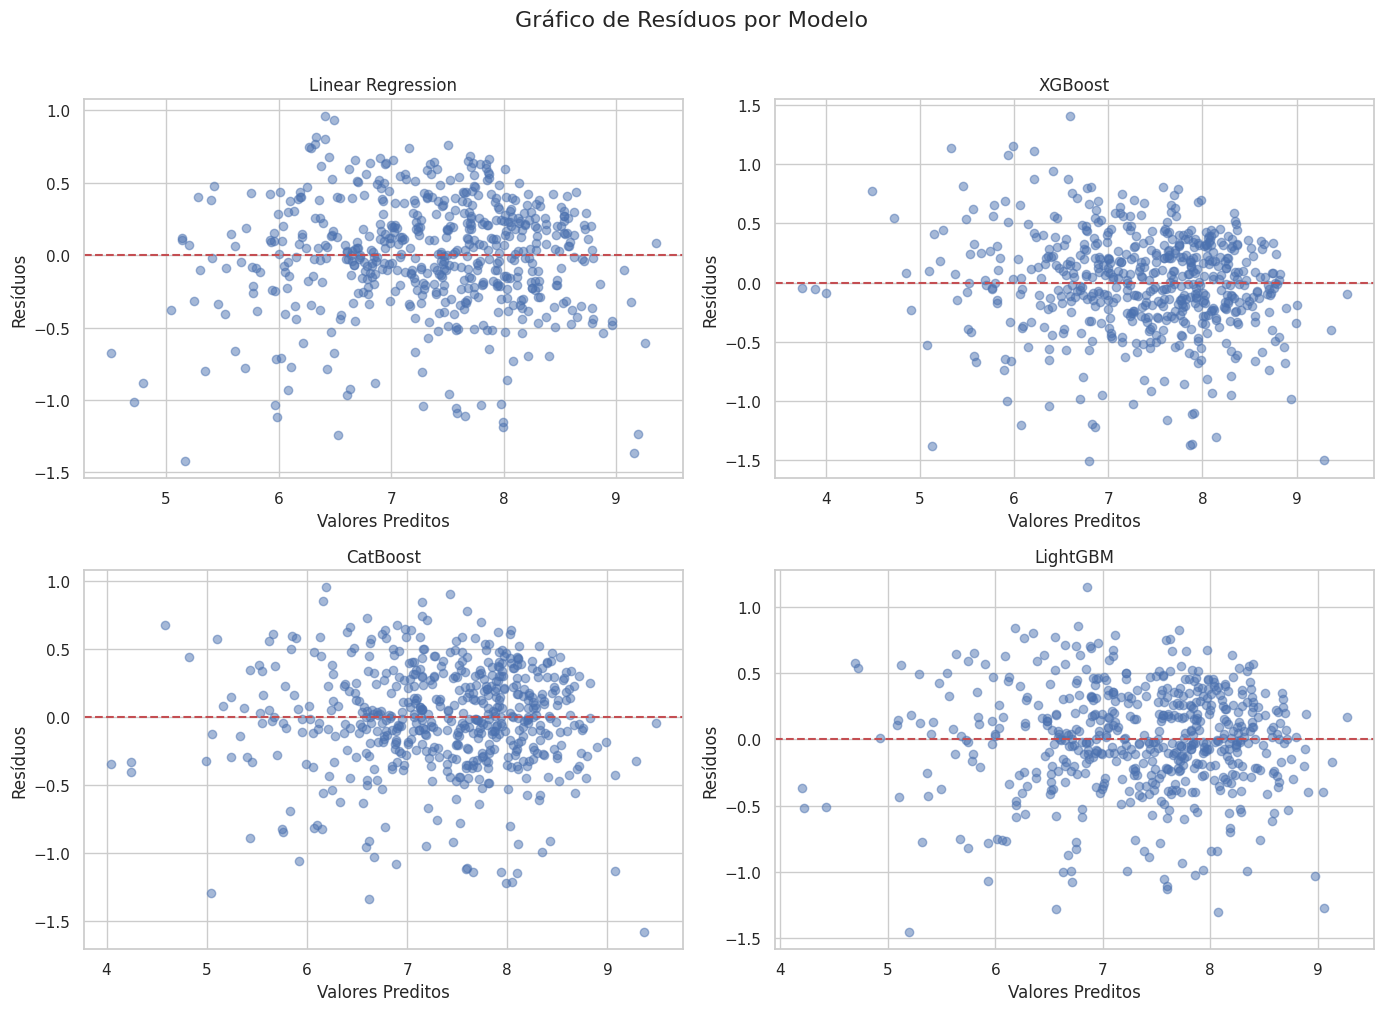

In [97]:
# 6.3. Gráficos de resíduos

n_models = len(trained_pipelines)
n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes = axes.flatten()

for i, (name, pipeline) in enumerate(trained_pipelines.items()):
    y_pred    = pipeline.predict(X_test)
    residuos  = y_test - y_pred

    axes[i].scatter(y_pred, residuos, alpha=0.5)
    axes[i].axhline(y=0, color='r', linestyle='--')
    axes[i].set_title(name)
    axes[i].set_xlabel('Valores Preditos')
    axes[i].set_ylabel('Resíduos')
    axes[i].grid(True)

# Remove subplots extras automaticamente
for j in range(n_models, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Gráfico de Resíduos por Modelo', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

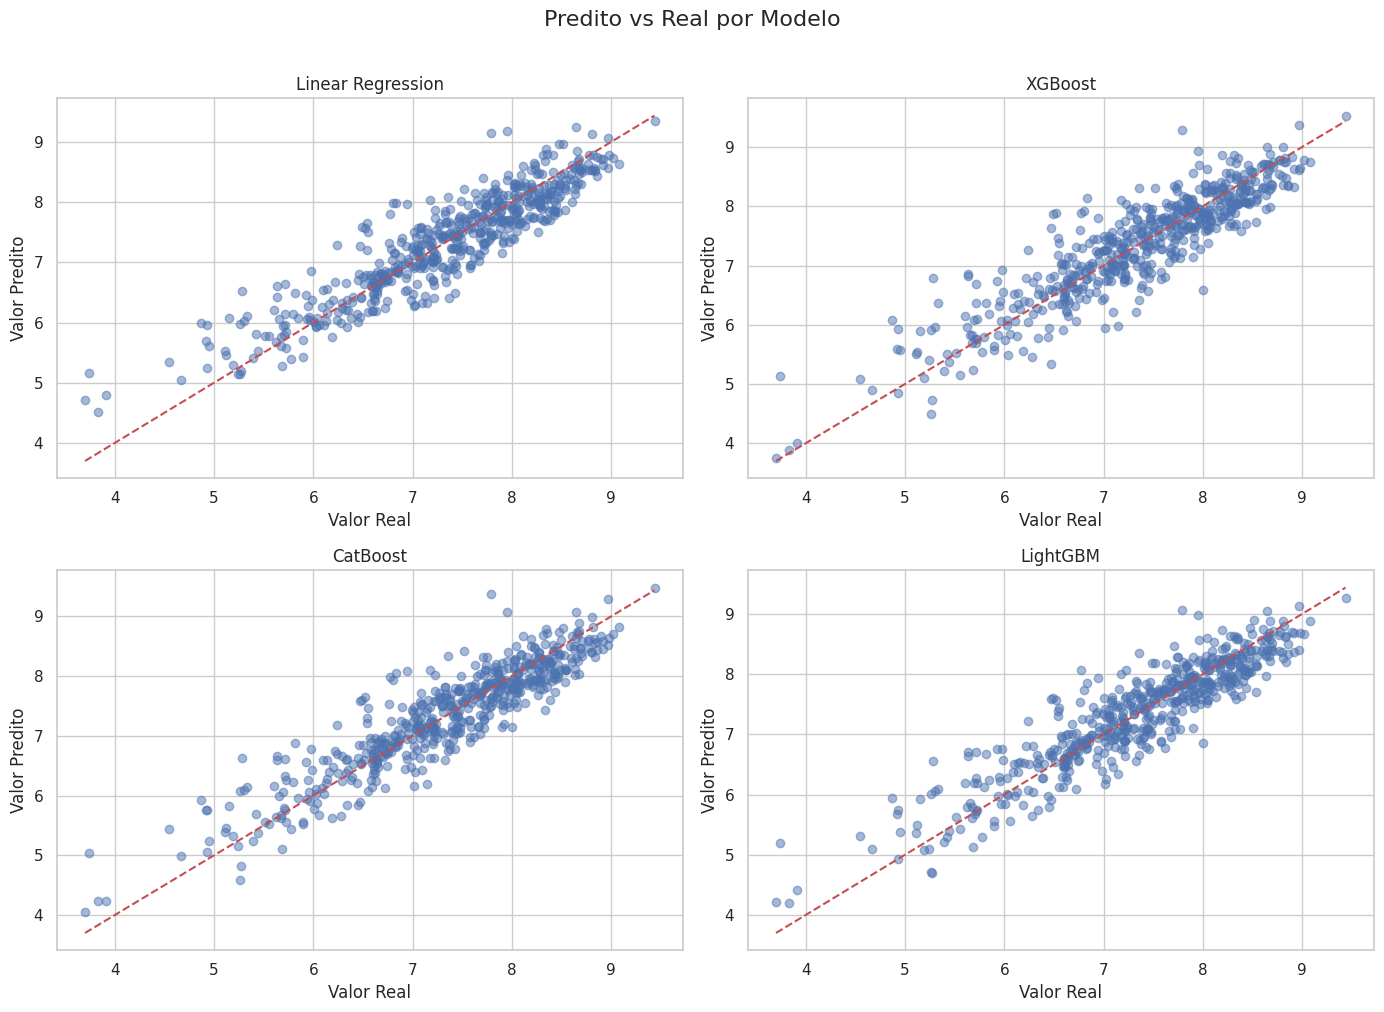

In [98]:
# 6.5. Gráficos de Predito vs Real

n_models = len(trained_pipelines)
n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes = axes.flatten()

for i, (name, pipeline) in enumerate(trained_pipelines.items()):
    y_pred = pipeline.predict(X_test)

    axes[i].scatter(y_test, y_pred, alpha=0.5)
    axes[i].plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()], 'r--')
    axes[i].set_title(name)
    axes[i].set_xlabel('Valor Real')
    axes[i].set_ylabel('Valor Predito')
    axes[i].grid(True)

# Remove subplots extras automaticamente
for j in range(n_models, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Predito vs Real por Modelo', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 8.3. Combinações de indicadores mais relevantes para o INDE

In [99]:
# 7. Importância de features
from sklearn.preprocessing import OneHotEncoder

def get_feature_names(preprocessor, numeric_features, categorical_features):
    # nomes numéricos = originais
    num_names = numeric_features

    ohe_names = []
    if categorical_features: # Only attempt to get names if there are categorical features
        # pegar o OneHotEncoder do transformer 'cat'
        ohe = preprocessor.named_transformers_['cat']
        ohe_names = ohe.get_feature_names_out(categorical_features)

    return list(num_names) + list(ohe_names)

# Fit the preprocessor before trying to get feature names
preprocessor.fit(X_train)

feature_names = get_feature_names(
    preprocessor,
    numeric_features,
    categorical_features
)
len(feature_names)  # só para conferir

6

In [100]:
def feature_importance_from_pipeline(name, pipeline, feature_names):
    # último step do pipeline
    model = pipeline.named_steps['model']   # ajuste se seu step tiver outro nome

    importances = None
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_)
    else:
        raise AttributeError(
            f"Model {type(model).__name__} does not have 'feature_importances_' or 'coef_' attribute."
        )

    df_imp = (
        pd.DataFrame({
            'Feature': feature_names,
            f'Importância_{name}': importances
        })
        .sort_values(f'Importância_{name}', ascending=False)
        .reset_index(drop=True)
    )
    return df_imp

In [101]:
imp_lr = feature_importance_from_pipeline(
    'Linear Regression',
    trained_pipelines['Linear Regression'],
    feature_names
)

imp_xgb = feature_importance_from_pipeline(
    'XGBoost',
    trained_pipelines['XGBoost'],
    feature_names
)

imp_cat = feature_importance_from_pipeline(
    'CatBoost',
    trained_pipelines['CatBoost'],
    feature_names
)

imp_lgb = feature_importance_from_pipeline(
    'LightGBM',
    trained_pipelines['LightGBM'],
    feature_names
)

In [102]:
# 7.1. Tabela única e ranking final: juntar tudo numa tabela só, pela coluna feature
def normalize_importances(importances):
    """Normaliza importâncias para somar 1.0"""
    return importances / importances.sum()

tabela_importancias = (
    imp_lr
    .merge(imp_xgb, on='Feature', how='outer')
    .merge(imp_cat, on='Feature', how='outer')
    .merge(imp_lgb, on='Feature', how='outer')
)

# normalizar cada coluna de importância
tabela_importancias['Importância_LR_norm'] = normalize_importances(
    tabela_importancias['Importância_Linear Regression']
)
tabela_importancias['Importância_XGB_norm'] = normalize_importances(
    tabela_importancias['Importância_XGBoost']
)
tabela_importancias['Importância_Cat_norm'] = normalize_importances(
    tabela_importancias['Importância_CatBoost']
)
tabela_importancias['Importância_LGB_norm'] = normalize_importances(
    tabela_importancias['Importância_LightGBM']
)

# agora fazer a média das normalizadas
tabela_importancias['Importância_Média_Normalizada'] = tabela_importancias[
    ['Importância_LR_norm', 'Importância_XGB_norm', 'Importância_Cat_norm', 'Importância_LGB_norm']
].mean(axis=1)

# ordenar pela média normalizada
tabela_importancias = tabela_importancias.sort_values(
    'Importância_Média_Normalizada', ascending=False
)

# mostrar top 20
tabela_importancias[['Feature', 'Importância_Média_Normalizada']].head(20)

,Feature,Importância_Média_Normalizada
0,IDA_IEG,0.416447
3,IEG_IPP,0.187557
2,IDA_IPS,0.106302
4,IEG_IPS,0.106295
5,IPS_IPP,0.105872
1,IDA_IPP,0.077525


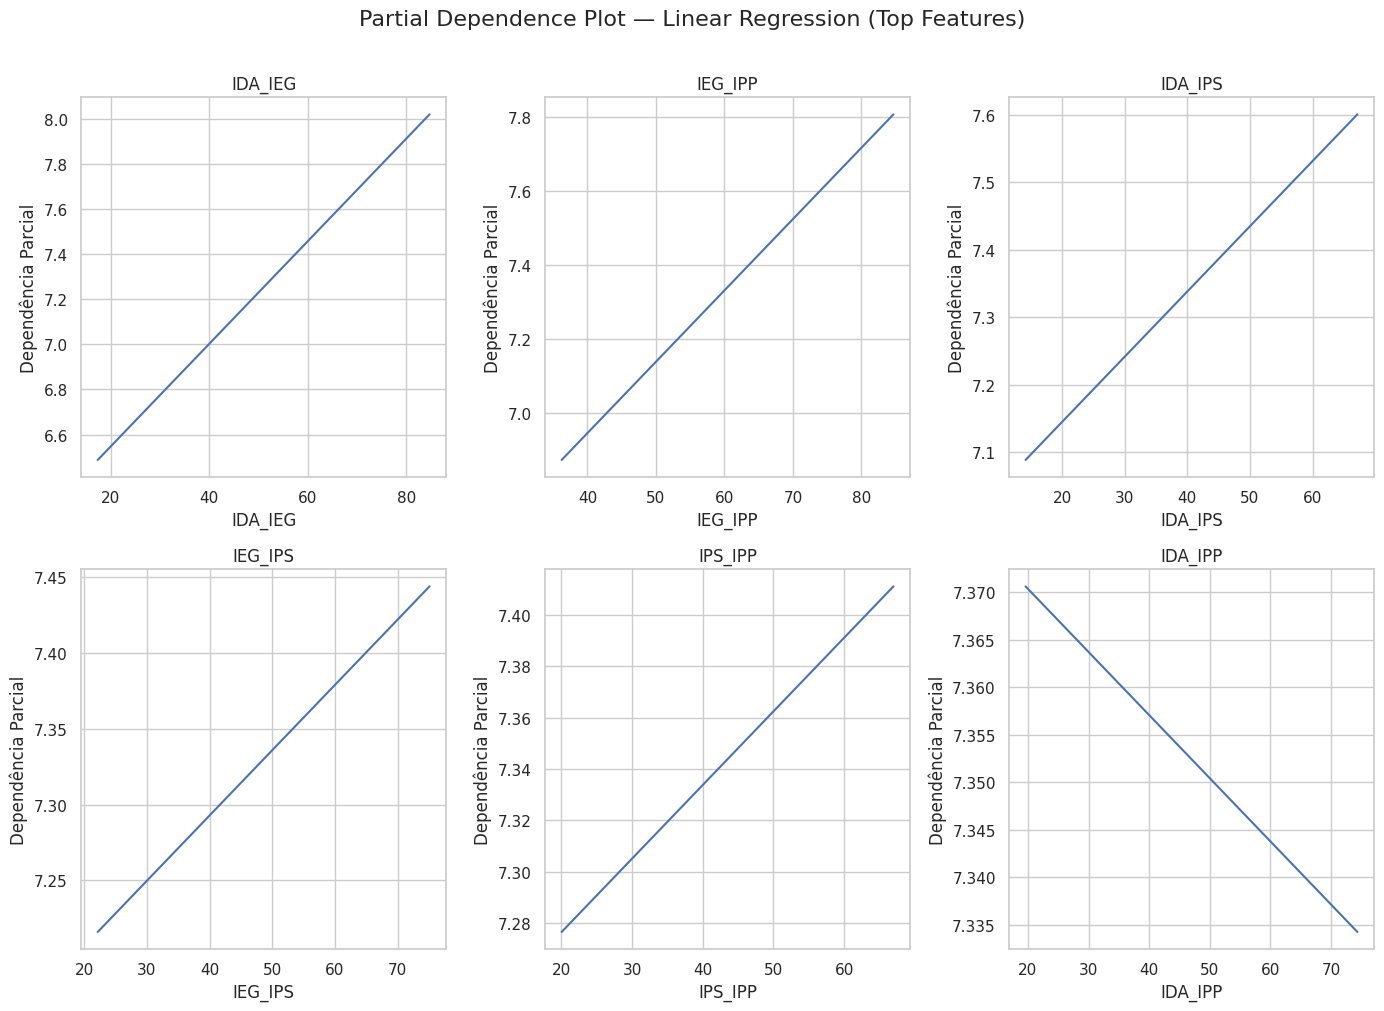

In [103]:
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

# para o modelo Linear Regression (melhor R²)
pipeline_lr = trained_pipelines['Linear Regression']

# Identificar os nomes das top 10 features numéricas do ranking
top_features_names = tabela_importancias['Feature'].head(10).tolist()

# Obter os índices dessas features no DataFrame original X_test
top_feature_indices = [X_test.columns.get_loc(f) for f in top_features_names if f in X_test.columns]

# --- Layout dinâmico ---
n_features = len(top_feature_indices)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes = axes.flatten()

# Calcular as dependências parciais manualmente para ter controle total do plot
for i, feature_idx in enumerate(top_feature_indices):
    pd_results = partial_dependence(
        pipeline_lr,
        X_test,
        features=[feature_idx],
        kind='average'
    )

    feature_values = pd_results['grid_values'][0]
    pd_values = pd_results['average'][0]
    feature_name = X_test.columns[feature_idx]

    axes[i].plot(feature_values, pd_values)
    axes[i].set_title(feature_name)
    axes[i].set_xlabel(feature_name)
    axes[i].set_ylabel('Dependência Parcial')
    axes[i].grid(True)

# Remove subplots extras automaticamente
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Partial Dependence Plot — Linear Regression (Top Features)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

Para investigar quais combinações de indicadores elevam mais a nota global do aluno (INDE), foram construídas seis variáveis de interação — produtos entre pares de indicadores (IDA × IEG, IDA × IPS, IDA × IPP, IEG × IPS, IEG × IPP e IPS × IPP) — e treinados quatro modelos de regressão: Regressão Linear, XGBoost, CatBoost e LightGBM, com separação por grupo de aluno para evitar vazamento de dados.

A avaliação de overfitting indicou que os modelos apresentam boa capacidade de generalização. A diferença entre R² de treino e teste foi inferior a 0,05 em todos os modelos, e a validação cruzada com GroupKFold de 5 folds confirmou que os resultados são estáveis entre as partições, sem flutuações relevantes de desempenho.

A análise de importância de features, calculada individualmente para cada modelo e normalizada para comparação direta, aponta que a combinação IDA × IEG (desempenho acadêmico com engajamento) apresenta a maior importância média entre os modelos, seguida da interação IEG × IPP (engajamento com avaliação psicopedagógica). Essas duas combinações concentram a maior parte do poder explicativo do INDE, sugerindo que o aluno que se engaja nas atividades e ao mesmo tempo apresenta bom desempenho acadêmico e acompanhamento psicopedagógico adequado tende a obter as notas globais mais elevadas. Os gráficos de dependência parcial confirmam que essas interações têm efeito positivo e crescente sobre o INDE, podendo contribuir com até **+1,75 pontos na nota global**, variação suficiente para migrar o aluno para uma categoria de pedra superior.

De forma geral, os resultados reforçam que o INDE é explicado pela **sinergia entre engajamento, desempenho e acompanhamento psicopedagógico**. Estratégias que atuem simultaneamente nessas três dimensões têm maior potencial de impacto sobre o desenvolvimento global do aluno do que intervenções pontuais em um único indicador.

## **9. Previsão de risco com Machine Learning: Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.**

### 9.1. Criando o Modelo preditivo de risco de defasagem

Vamos definir uma variável binária para representar o nível de defasagem. Vamos considerar como risco = 1 quando Defasagem < 0, e risco = 0 para Defasagem >= 0.

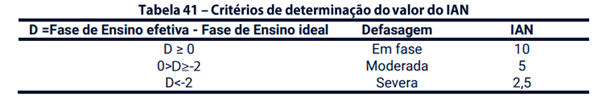

In [104]:
# 1. Separação de Features (X) e Alvo (y)

# 1.1. Criar defasagem futura
df_consolidado = df_consolidado.sort_values(['RA', 'ano'])
df_consolidado['Defasagem_fut'] = df_consolidado.groupby('RA')['Defasagem'].shift(-1)

# 1.2. Remover linhas sem próximo ano
df_risco = df_consolidado.dropna(subset=['Defasagem_fut']).copy()

# 1.3. Criar alvo binário
df_risco['risco_defasagem'] = (df_risco['Defasagem_fut'] < 0).astype(int)

df_risco.info()
# 1.4. Definir X SEM Defasagem nem Defasagem_fut
X_risco = df_risco[['Mat','Por','Ing','IDA','IEG','IPS','IPP','IAN',
                    'Fase','Fase Ideal','Idade','Ano ingresso','ano',
                    'Instituição de ensino','Turma','Gênero']]

y_risco = df_risco['risco_defasagem']

# 1.5. O RA identifica cada aluno único
groups_risco = df_risco['RA']

<class 'pandas.core.frame.DataFrame'>
Index: 1258 entries, 1072 to 1064
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   IDA                    1258 non-null   float64
 1   Defasagem              1258 non-null   int64  
 2   Turma                  1258 non-null   object 
 3   Pedra                  1258 non-null   object 
 4   Pedra 21               557 non-null    object 
 5   Ing                    1258 non-null   float64
 6   IEG                    1258 non-null   float64
 7   Cg                     580 non-null    float64
 8   IAN                    1258 non-null   float64
 9   INDE                   1258 non-null   float64
 10  IAA                    1258 non-null   float64
 11  Mat                    1258 non-null   float64
 12  Fase                   1258 non-null   int64  
 13  Gênero                 1258 non-null   object 
 14  Por                    1258 non-null   float64
 15  Instit

In [105]:
print(df_risco.columns)

Index(['IDA', 'Defasagem', 'Turma', 'Pedra', 'Pedra 21', 'Ing', 'IEG', 'Cg',
       'IAN', 'INDE', 'IAA', 'Mat', 'Fase', 'Gênero', 'Por',
       'Instituição de ensino', 'Ano ingresso', 'RA', 'Ct', 'Idade', 'Cf',
       'IPP', 'Fase Ideal', 'ano', 'Nome', 'IPV', 'IPS', 'Pedra 20', 'IDA_IEG',
       'IDA_IPS', 'IDA_IPP', 'IEG_IPS', 'IEG_IPP', 'IPS_IPP', 'Defasagem_fut',
       'risco_defasagem'],
      dtype='object')


In [106]:
# 1.6. Identificar colunas numéricas e categóricas

numeric_features_risco = X_risco.select_dtypes(include='number').columns.tolist()
categorical_features_risco = X_risco.select_dtypes(include='object').columns.tolist()

print(numeric_features_risco)
print(categorical_features_risco)

['Mat', 'Por', 'Ing', 'IDA', 'IEG', 'IPS', 'IPP', 'IAN', 'Fase', 'Fase Ideal', 'Idade', 'Ano ingresso', 'ano']
['Instituição de ensino', 'Turma', 'Gênero']


In [107]:
# 2. Criação do Pipeline de Pré-processamento
preprocessor_risco = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_risco),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features_risco)
    ])

In [108]:
# 3. Divisão em Dados de Treino e Teste

gss_risco = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx_risco, test_idx_risco = next(gss_risco.split(X_risco, y_risco, groups=groups_risco))

X_train_risco, X_test_risco = X_risco.iloc[train_idx_risco], X_risco.iloc[test_idx_risco]
y_train_risco, y_test_risco = y_risco.iloc[train_idx_risco], y_risco.iloc[test_idx_risco]

# Encode y_train and y_test to ensure non-negative, zero-indexed classes for classifiers
label_encoder = LabelEncoder()
y_train_risco = label_encoder.fit_transform(y_train_risco)
y_test_risco  = label_encoder.transform(y_test_risco)
groups_train = groups_risco.iloc[train_idx_risco].reset_index(drop=True)  # <- corrige o índice sem perder o formato

In [109]:
# 4. Definição dos Modelos
modelos_classifier = {
    'Regressao Logistica': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,  # IMPORTANTE: Evita warnings
        eval_metric='mlogloss',   # Métrica para multiclasse
        enable_categorical=False   #
    ),
    'CatBoost': CatBoostClassifier(
        iterations=100,
        depth=6,
        learning_rate=0.1,
        random_state=42,
        verbose=False,
        allow_writing_files=False  # Evita criar arquivos temporários
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbose=-1,
        force_col_wise=True, # Evita warnings
        num_leaves=20,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1
    )
}

In [110]:
# 5. Loop para Treinar, Avaliar e Salvar cada Modelo

# Dicionário para armazenar os pipelines treinados
trained_pipelines_risco = {}

for name, model_instance in modelos_classifier.items():
    # Criação do Pipeline Completo (Pré-processamento + Modelo)
    pipeline_risco = Pipeline(steps=[('preprocessor', preprocessor_risco),
                             ('classifier', model_instance)])

    # Treinar o modelo
    print(f"--- Treinando o modelo: {name} ---")
    pipeline_risco.fit(X_train_risco, y_train_risco)

    # Predição de classe
    y_pred_risco = pipeline_risco.predict(X_test_risco)

    # Probabilidade de risco (classe positiva)
    y_prob_risco = pipeline_risco.predict_proba(X_test_risco)[:, 1]

    # Métricas de Avaliação do Modelo
    y_pred_risco = pipeline_risco.predict(X_test_risco)
    accuracy = accuracy_score(y_test_risco, y_pred_risco)
    auc_roc = roc_auc_score(y_test_risco, y_prob_risco)

    print(f"Acurácia no conjunto de teste: {accuracy * 100:.2f}%")
    print(f"AUC-ROC no conjunto de teste:  {auc_roc:.4f}")

    # Relatório de Classificação Detalhado
    print("\n--- Relatório de Classificação ---")
    # Use target_names to map encoded labels back to original for readability
    print(classification_report(y_test_risco, y_pred_risco, target_names=label_encoder.classes_.astype(str)))

    # Salvar o modelo treinado
    model_filename = f"{name.lower().replace(' ', '_')}_model.pkl"
    joblib.dump(pipeline_risco, model_filename)
    print(f"Modelo salvo como '{model_filename}'")
    print("="*50 + "\n")

    # Salvar o pipeline em memória
    trained_pipelines_risco[name] = pipeline_risco

--- Treinando o modelo: Regressao Logistica ---
Acurácia no conjunto de teste: 79.30%
AUC-ROC no conjunto de teste:  0.8870

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.82      0.75      0.78       127
           1       0.77      0.84      0.80       129

    accuracy                           0.79       256
   macro avg       0.80      0.79      0.79       256
weighted avg       0.80      0.79      0.79       256

Modelo salvo como 'regressao_logistica_model.pkl'

--- Treinando o modelo: SVM ---
Acurácia no conjunto de teste: 79.69%
AUC-ROC no conjunto de teste:  0.8916

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.87      0.69      0.77       127
           1       0.75      0.90      0.82       129

    accuracy                           0.80       256
   macro avg       0.81      0.80      0.79       256
weighted avg       0.81      0.80      0.79   

### 9.2. Verificações de Overfitting

In [111]:
# 6. Verificação de Overfitting

# 6.1. Comparação Treino vs Teste
resultados_accuracy_risco = []

for name, pipeline in trained_pipelines_risco.items():
    y_train_pred_risco = pipeline.predict(X_train_risco)
    y_test_pred_risco = pipeline.predict(X_test_risco)
    train_accuracy_risco = accuracy_score(y_train_risco, y_train_pred_risco)
    test_accuracy_risco = accuracy_score(y_test_risco, y_test_pred_risco)
    resultados_accuracy_risco.append({
        'Modelo': name,
        'Acuracidade Treino': round(train_accuracy_risco, 4),
        'Acuracidade Teste': round(test_accuracy_risco, 4),
        'Diferença': round(train_accuracy_risco - test_accuracy_risco, 4),
        'OBS': '✅ Modelo generaliza bem' if (train_accuracy_risco - test_accuracy_risco) < 0.05 else '⚠️ POSSÍVEL OVERFITTING!'
    })

tabela_accuracy_risco = pd.DataFrame(resultados_accuracy_risco)
tabela_accuracy_risco

,Modelo,Acuracidade Treino,Acuracidade Teste,Diferença,OBS
0,Regressao Logistica,0.8234,0.7930,0.0304,✅ Modelo generaliza bem
1,SVM,0.8553,0.7969,0.0584,⚠️ POSSÍVEL OVERFITTING!
2,Random Forest,0.8373,0.8086,0.0287,✅ Modelo generaliza bem
3,XGBoost,0.9800,0.8555,0.1246,⚠️ POSSÍVEL OVERFITTING!
4,CatBoost,0.9361,0.8438,0.0924,⚠️ POSSÍVEL OVERFITTING!
5,LightGBM,0.9511,0.8711,0.0800,⚠️ POSSÍVEL OVERFITTING!


In [112]:
# 6.2. Cross-Validation

gkf = GroupKFold(n_splits=5)
resultados_cv_risco = []

for name, model_instance in modelos_classifier.items():
    # Criar um pipeline novo (não treinado) para o CV
    pipeline_cv = Pipeline(steps=[('preprocessor', preprocessor_risco),
                              ('classifier', model_instance)])

    # Avaliar com 5-fold cross-validation
    cv_scores = cross_val_score(pipeline_cv, X_train_risco, y_train_risco, cv=gkf, groups=groups_train, scoring='accuracy')

    # Pegar a acurácia no teste do pipeline já treinado
    test_accuracy = accuracy_score(y_test_risco, trained_pipelines_risco[name].predict(X_test_risco))

    # Cria a tabela de comparação
    resultados_cv_risco.append({
        'Modelo': name,
        'Acurácia média (CV)': round(cv_scores.mean(), 4),
        'Desvio padrão (CV)': round(cv_scores.std(), 4),
        'Acurácia no teste': round(test_accuracy, 4),
        'Diferença': round(cv_scores.mean() - test_accuracy, 4),
        'OBS_CV': '✅ Modelo generaliza bem' if (cv_scores.mean() - test_accuracy) < 0.05 else '⚠️ Diferença entre CV e teste - verificar melhor',
        'OBS_DP': '✅ Modelo estável' if cv_scores.std() < 0.05 else '⚠️ Modelo instável (alto desvio padrão)'
    })

tabela_cv_risco = pd.DataFrame(resultados_cv_risco)
tabela_cv_risco

,Modelo,Acurácia média (CV),Desvio padrão (CV),Acurácia no teste,Diferença,OBS_CV,OBS_DP
0,Regressao Logistica,0.7855,0.0382,0.7930,-0.0075,✅ Modelo generaliza bem,✅ Modelo estável
1,SVM,0.7845,0.0309,0.7969,-0.0124,✅ Modelo generaliza bem,✅ Modelo estável
2,Random Forest,0.7835,0.0272,0.8086,-0.0251,✅ Modelo generaliza bem,✅ Modelo estável
3,XGBoost,0.8024,0.0239,0.8555,-0.0530,✅ Modelo generaliza bem,✅ Modelo estável
4,CatBoost,0.8114,0.0321,0.8438,-0.0323,✅ Modelo generaliza bem,✅ Modelo estável
5,LightGBM,0.8035,0.0351,0.8711,-0.0676,✅ Modelo generaliza bem,✅ Modelo estável


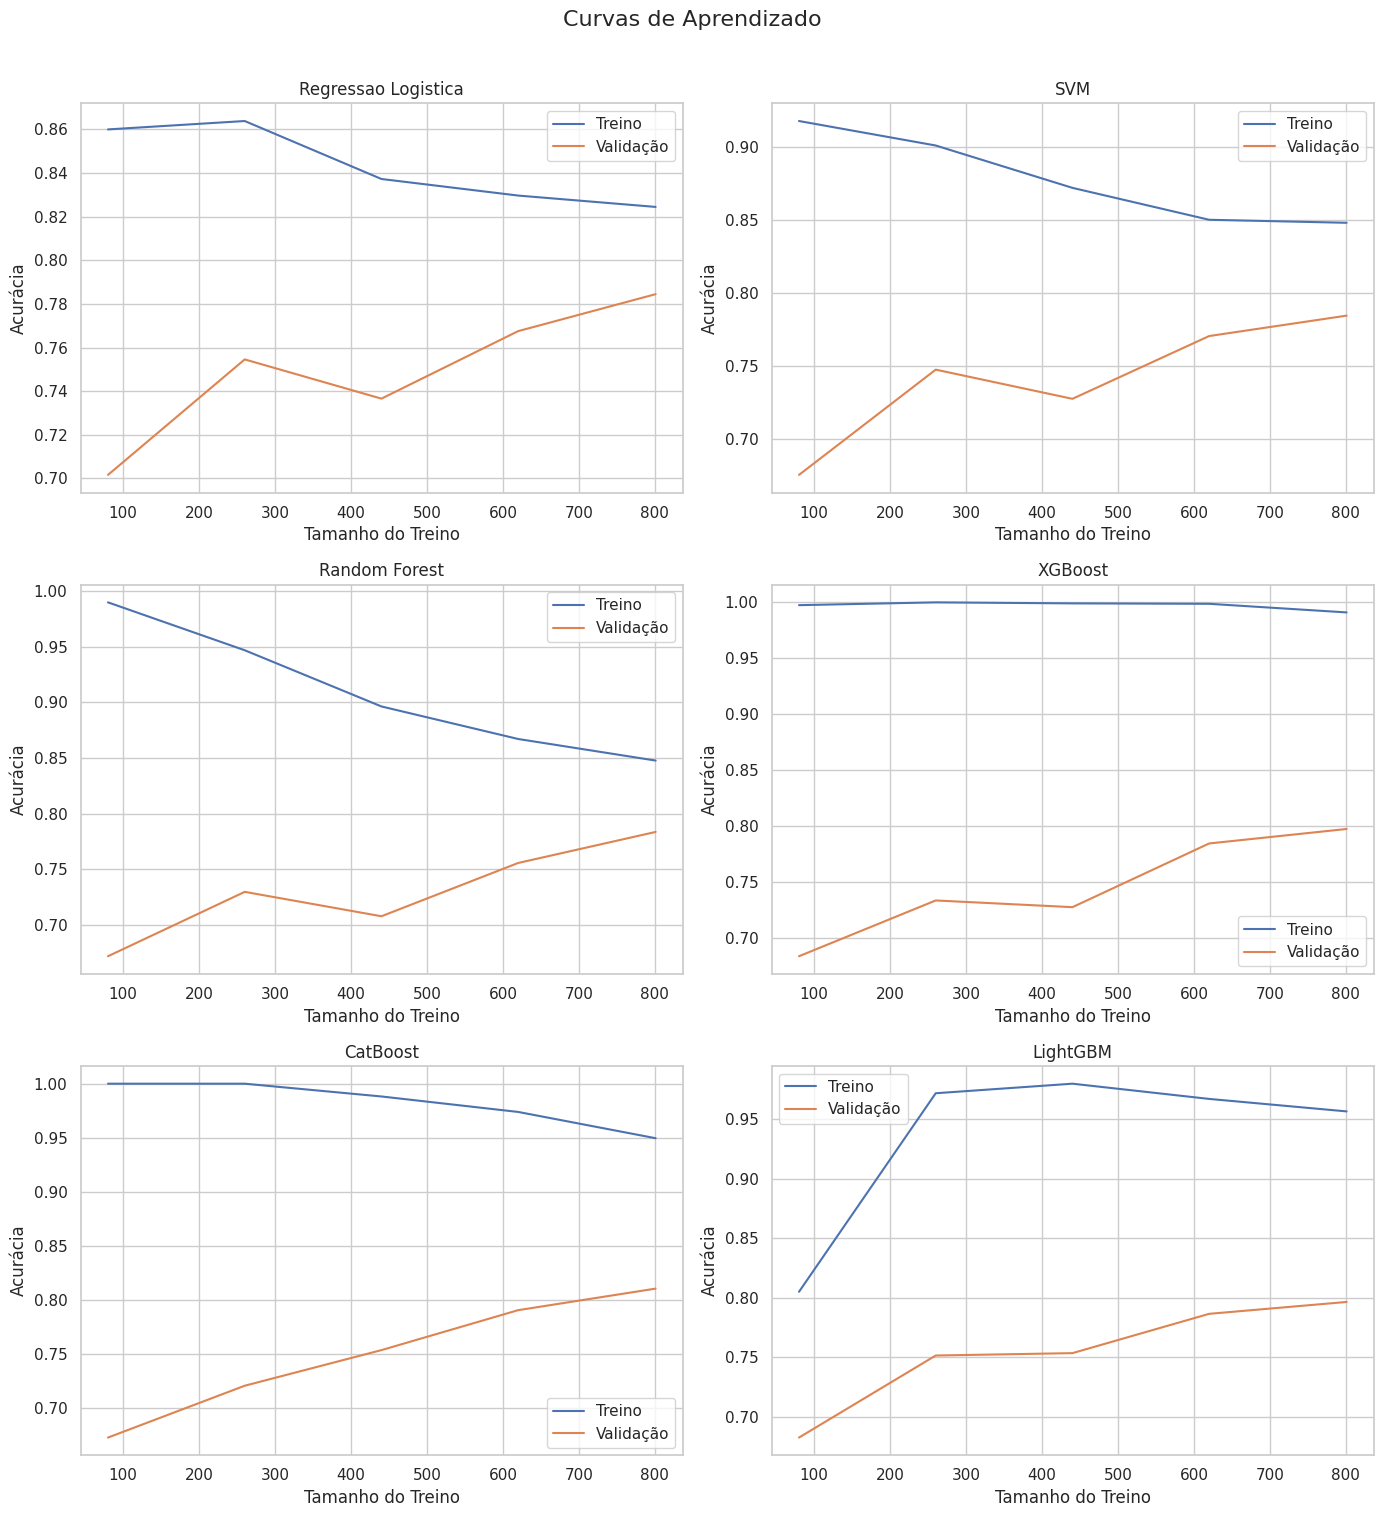

In [113]:
# 6.3. Curvas de Aprendizado

from sklearn.model_selection import learning_curve

n_models_risco = len(trained_pipelines_risco)
n_cols = 2
n_rows_risco = math.ceil(n_models_risco / n_cols)

fig, axes = plt.subplots(n_rows_risco, n_cols, figsize=(14, n_rows_risco * 5))
axes = axes.flatten()
resultados_ca_risco = []

for i, (name, pipeline) in enumerate(trained_pipelines_risco.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X_train_risco, y_train_risco, cv=gkf, groups=groups_train, scoring='accuracy', n_jobs=-1
    )

    # Calcular médias e desvios padrão
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    # Tabela de Performance dos modelos
    resultados_ca_risco.append({
        'Modelo': name,
        'Acurácia final no treino': round(train_mean[-1], 4),
        'Acurácia final na validação': round(val_mean[-1], 4),
        'Gap (diferença)': round(train_mean[-1] - val_mean[-1], 4),
        'OBS': '✅ As curvas convergem - NÃO há overfitting' if (train_mean[-1] - val_mean[-1]) < 0.05
                else ('⚠️ Gap moderado - Possível leve overfitting' if (train_mean[-1] - val_mean[-1]) < 0.10 else '🚨 Gap grande - Overfitting significativo!')
    })

    axes[i].plot(train_sizes, train_mean, label='Treino')
    axes[i].plot(train_sizes, val_mean,   label='Validação')
    axes[i].set_title(name)
    axes[i].set_xlabel('Tamanho do Treino')
    axes[i].set_ylabel('Acurácia')
    axes[i].legend()
    axes[i].grid(True)

# Remove subplots extras automaticamente
for k in range(n_models_risco, len(axes)):
    fig.delaxes(axes[k])

plt.suptitle('Curvas de Aprendizado', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [114]:
# Análise das Curvas de Aprendizado

tabela_ca_risco = pd.DataFrame(resultados_ca_risco)
tabela_ca_risco

,Modelo,Acurácia final no treino,Acurácia final na validação,Gap (diferença),OBS
0,Regressao Logistica,0.8245,0.7845,0.0400,✅ As curvas convergem - NÃO há overfitting
1,SVM,0.8479,0.7845,0.0635,⚠️ Gap moderado - Possível leve overfitting
2,Random Forest,0.8477,0.7835,0.0642,⚠️ Gap moderado - Possível leve overfitting
3,XGBoost,0.9910,0.7974,0.1936,🚨 Gap grande - Overfitting significativo!
4,CatBoost,0.9496,0.8104,0.1391,🚨 Gap grande - Overfitting significativo!
5,LightGBM,0.9563,0.7965,0.1598,🚨 Gap grande - Overfitting significativo!


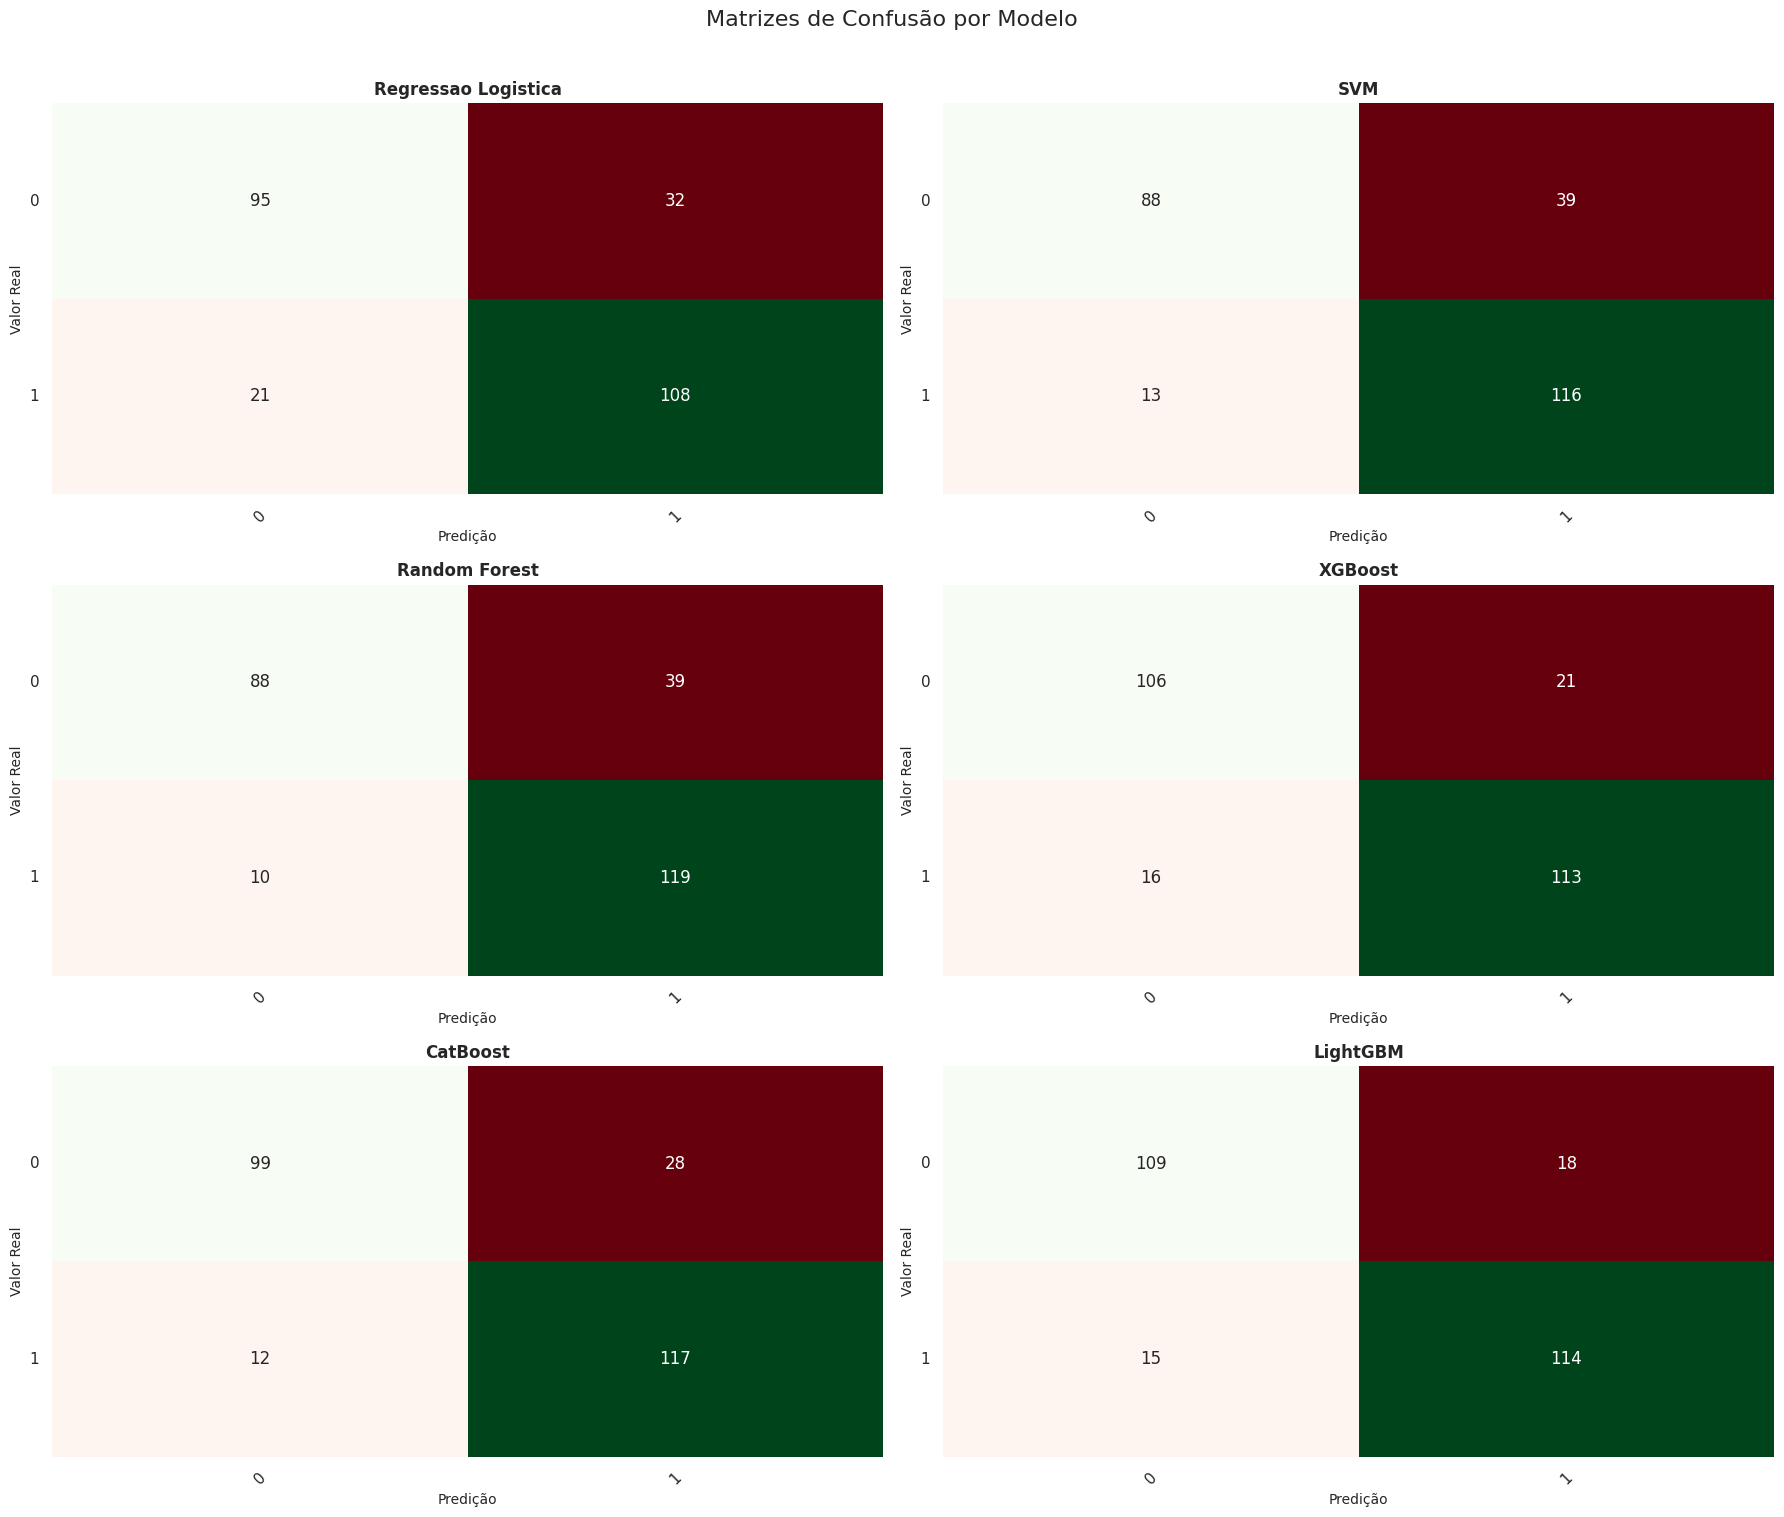

In [115]:
# 6.4. Matrizes de Confusão - Gráficos

from sklearn.metrics import confusion_matrix

# Mapeamento das classes
classes_mapping = dict(enumerate(label_encoder.classes_))
class_labels = [classes_mapping.get(i, f'Classe {i}') for i in sorted(np.unique(y_test_risco))]

n_models_risco = len(trained_pipelines_risco)
n_cols = 2
n_rows_risco = math.ceil(n_models_risco / n_cols)

fig, axes = plt.subplots(n_rows_risco, n_cols, figsize=(18, n_rows_risco * 5))
axes = axes.flatten()

for i, (name, pipeline) in enumerate(trained_pipelines_risco.items()):
    y_pred_risco = pipeline.predict(X_test_risco)
    cm = confusion_matrix(y_test_risco, y_pred_risco)

    mask_diag  = np.eye(len(cm), dtype=bool)
    tick_labels = label_encoder.classes_.astype(str)

    # Erros em vermelho (fora da diagonal)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                mask=mask_diag,
                xticklabels=tick_labels,
                yticklabels=tick_labels,
                cbar=False,
                ax=axes[i])

    # Acertos em verde (diagonal)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                mask=~mask_diag,
                xticklabels=tick_labels,
                yticklabels=tick_labels,
                cbar=False,
                ax=axes[i])

    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predição', fontsize=10)
    axes[i].set_ylabel('Valor Real', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].tick_params(axis='y', rotation=0)

# Remove subplots extras automaticamente
# for r in range(n_models, len(axes)): # This loop is no longer needed as n_models_risco == len(axes)
#    fig.delaxes(axes[r])

plt.suptitle('Matrizes de Confusão por Modelo', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

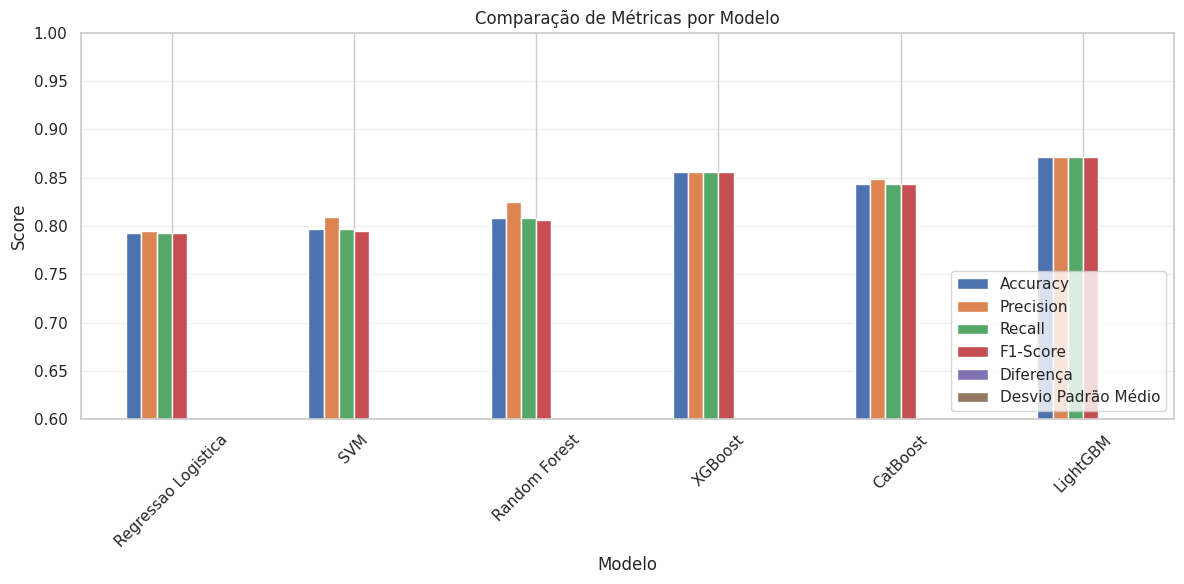


🏆 MELHOR MODELO (baseado na Diferença de Acuracidade entre treino e teste): Random Forest


In [116]:
# 6.5.1. Verificação de Overfitting: Comparar Múltiplas Métricas

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Criar um DataFrame para comparar métricas
results_risco = []

for name, pipeline in trained_pipelines_risco.items():
    # Predições no teste
    y_pred_risco = pipeline.predict(X_test_risco)
    y_train_pred_risco = pipeline.predict(X_train_risco)
    train_accuracy_risco = accuracy_score(y_train_risco, y_train_pred_risco)
    test_accuracy_risco = accuracy_score(y_test_risco, y_pred_risco)

    # Calcular todas as métricas
    accuracy = accuracy_score(y_test_risco, y_pred_risco)
    precision = precision_score(y_test_risco, y_pred_risco, average='weighted', zero_division=0)
    recall = recall_score(y_test_risco, y_pred_risco, average='weighted', zero_division=0)
    f1 = f1_score(y_test_risco, y_pred_risco, average='weighted', zero_division=0)
    diferenca = train_accuracy_risco - test_accuracy_risco

    # Verificar consistência entre métricas
    metrics = [accuracy, precision, recall, f1]
    std_metrics = np.std(metrics)

    results_risco.append({
        'Modelo': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Diferença': round(diferenca, 4),
        'Desvio Padrão Médio': std_metrics,
        'OBS': '✅ Métricas consistentes - modelo balanceado' if std_metrics < 0.05 else '⚠️ Métricas inconsistentes - verificar desbalanceamento'
    })

# Criar DataFrame para visualização
df_results_risco = pd.DataFrame(results_risco)

# Visualização gráfica
df_results_risco.set_index('Modelo').plot(kind='bar', figsize=(12, 6), rot=45)
plt.title('Comparação de Métricas por Modelo')
plt.ylabel('Score')
plt.xlabel('Modelo')
plt.legend(loc='lower right')
plt.ylim(0.6, 1.0)  # Ajustar conforme seus resultados
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Identificar o melhor modelo
best_model = df_results_risco.loc[df_results_risco['Diferença'].idxmin(), 'Modelo']
print(f"\n🏆 MELHOR MODELO (baseado na Diferença de Acuracidade entre treino e teste): {best_model}")

In [117]:
# 6.5.2. Verificação de Overfitting: Criar DataFrame para visualização

print("\n" + "="*60)
print("RESUMO COMPARATIVO DE TODOS OS MODELOS:")
print(f"\n🏆 MELHOR MODELO (baseado na Diferença de Acuracidade entre treino e teste): {best_model}")
print("="*60)
df_results_risco


RESUMO COMPARATIVO DE TODOS OS MODELOS:

🏆 MELHOR MODELO (baseado na Diferença de Acuracidade entre treino e teste): Random Forest


,Modelo,Accuracy,Precision,Recall,F1-Score,Diferença,Desvio Padrão Médio,OBS
0,Regressao Logistica,0.792969,0.795011,0.792969,0.792516,0.0304,0.000968,✅ Métricas consistentes - modelo balanceado
1,SVM,0.796875,0.809357,0.796875,0.794591,0.0584,0.005810,✅ Métricas consistentes - modelo balanceado
2,Random Forest,0.808594,0.824996,0.808594,0.805929,0.0287,0.007566,✅ Métricas consistentes - modelo balanceado
3,XGBoost,0.855469,0.855968,0.855469,0.855392,0.1246,0.000230,✅ Métricas consistentes - modelo balanceado
4,CatBoost,0.843750,0.849062,0.843750,0.843060,0.0924,0.002416,✅ Métricas consistentes - modelo balanceado
5,LightGBM,0.871094,0.871274,0.871094,0.871064,0.0800,0.000083,✅ Métricas consistentes - modelo balanceado


### 9.3. Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem?

In [118]:
# 7. Importância de features
from sklearn.preprocessing import OneHotEncoder

def get_feature_names_risco(preprocessor, numeric_features, categorical_features):
    # nomes numéricos = originais
    num_names = numeric_features_risco

    ohe_names = []
    if categorical_features_risco: # só traz para análise variáveis categóricas se houverem
        # pegar o OneHotEncoder do transformer 'cat'
        ohe = preprocessor_risco.named_transformers_['cat']
        ohe_names = ohe.get_feature_names_out(categorical_features_risco)

    return list(num_names) + list(ohe_names)

# Faz um fit no preprocessor antes de buscar os nomes das features
preprocessor_risco.fit(X_train_risco)

feature_names_risco = get_feature_names_risco(
    preprocessor_risco,
    numeric_features_risco,
    categorical_features_risco
)
len(feature_names_risco)  # só para conferir

121

In [119]:
def feature_importance_from_pipeline_risco(name, pipeline, feature_names):
    # último step do pipeline
    model = pipeline.named_steps['classifier']

    importances = None
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_).flatten()
    else:
        raise AttributeError(
            f"Model {type(model).__name__} does not have 'feature_importances_' or 'coef_' attribute."
        )

    df_imp = (
        pd.DataFrame({
            'Feature': feature_names,
            f'Importância_{name}': importances
        })
        .sort_values(f'Importância_{name}', ascending=False)
        .reset_index(drop=True)
    )
    return df_imp

In [120]:
# 7.1. Tabela única e ranking final: juntar tudo numa tabela só, pela coluna feature
def normalize_importances(importances):
    """Normaliza importâncias para somar 1.0"""
    return importances / importances.sum()

# Melhor modelo selecionado: Random Forest, por ter maior capacidade de generalização.
tabela_importancias_risco = feature_importance_from_pipeline_risco(
    'Random Forest',
    trained_pipelines_risco['Random Forest'],
    feature_names_risco
)

# normalizar cada coluna de importância
tabela_importancias_risco['Importância_RF_norm'] = normalize_importances(
    tabela_importancias_risco['Importância_Random Forest']
)

# ordenar pela média normalizada
tabela_importancias_risco = tabela_importancias_risco.sort_values(
    'Importância_RF_norm', ascending=False
)

# mostrar top 10
tabela_importancias_risco[['Feature', 'Importância_RF_norm']].head(10)

,Feature,Importância_RF_norm
0,IPP,0.185007
1,IAN,0.109444
2,Fase,0.096462
3,Idade,0.061260
4,IDA,0.055496
5,Por,0.053716
6,Fase Ideal,0.053082
7,Instituição de ensino_Escola Pública,0.044272
8,Ing,0.043904
9,IEG,0.043102


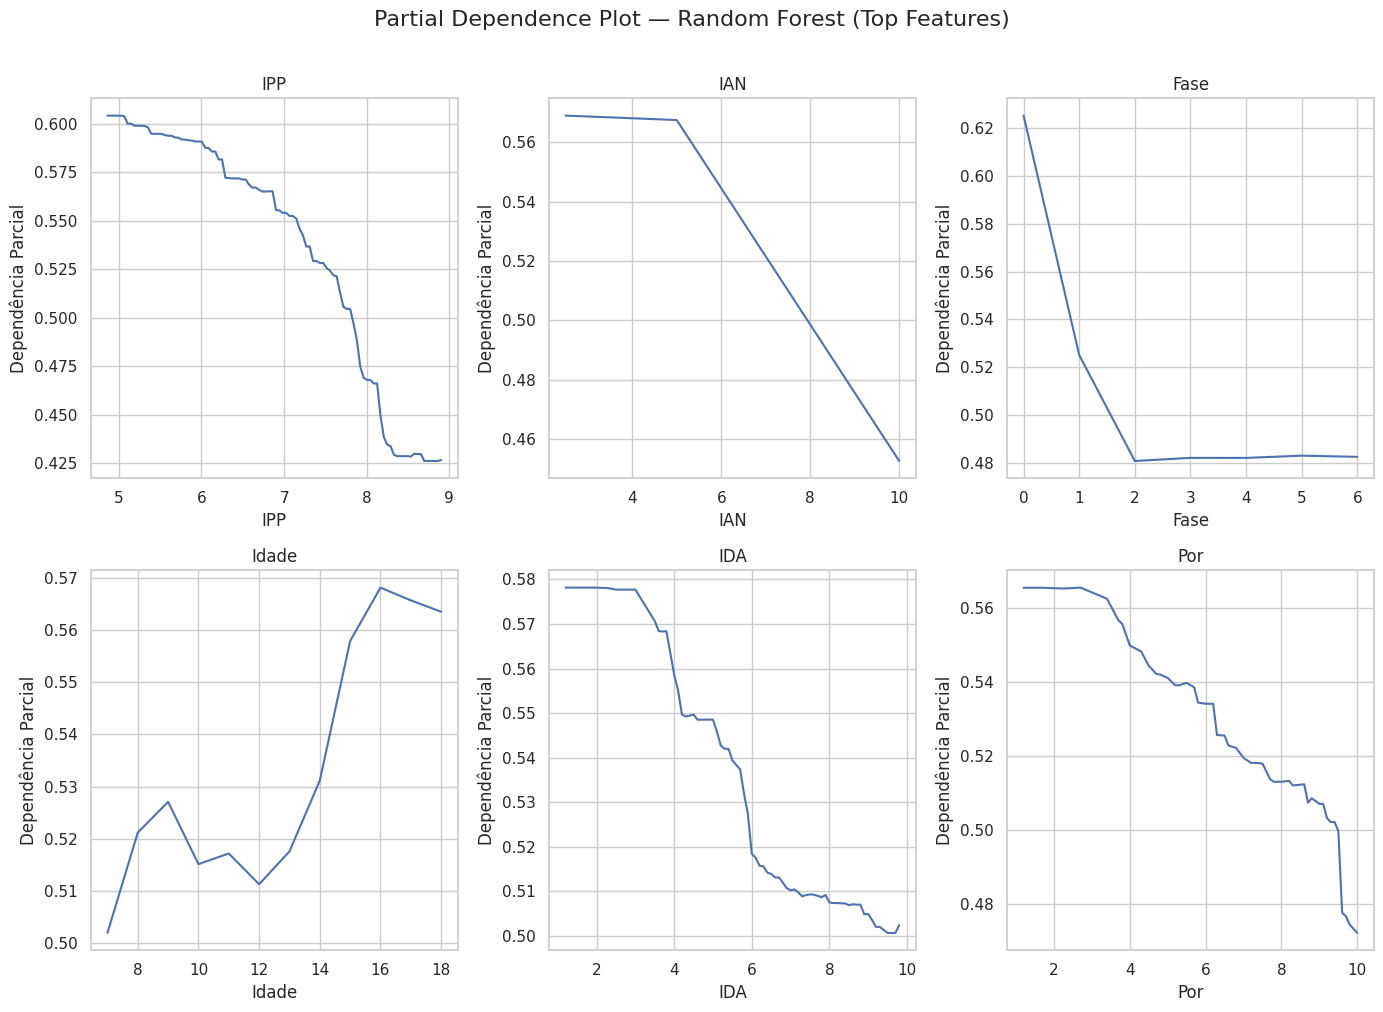

In [121]:
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

# para o modelo Random Forest (melhor generalização)
pipeline_rf_risco = trained_pipelines_risco['Random Forest']

# Identificar os nomes das top 10 features numéricas do ranking
top_features_names_risco = tabela_importancias_risco['Feature'].head(6).tolist()

# Obter os índices dessas features no DataFrame original X_test
top_feature_indices_risco = [X_test_risco.columns.get_loc(f) for f in top_features_names_risco if f in X_test_risco.columns]

# --- Layout dinâmico ---
n_features_risco = len(top_feature_indices_risco)
n_cols = 3
n_rows_risco = math.ceil(n_features_risco / n_cols)

fig, axes = plt.subplots(n_rows_risco, n_cols, figsize=(14, n_rows_risco * 5))
axes = axes.flatten()

# Calcular as dependências parciais manualmente para ter controle total do plot
for i, feature_idx in enumerate(top_feature_indices_risco):
    pd_results = partial_dependence(
        pipeline_rf_risco,
        X_test_risco,
        features=[feature_idx],
        kind='average'
    )

    feature_values = pd_results['grid_values'][0]
    pd_values = pd_results['average'][0]
    feature_name = X_test_risco.columns[feature_idx] # Corrected to use X_test_risco.columns

    axes[i].plot(feature_values, pd_values)
    axes[i].set_title(feature_name)
    axes[i].set_xlabel(feature_name)
    axes[i].set_ylabel('Dependência Parcial')
    axes[i].grid(True)

# Remove subplots extras automaticamente
for j in range(n_features_risco, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Partial Dependence Plot — {best_model} (Top Features)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 9.4. Análise do perfil de alunos de alto risco

In [122]:
# Seleciona o melhor modelo
# best_model = 'Random Forest'
model = trained_pipelines_risco[best_model]

# Montar dataframe de resultados
df_analise_risco = X_test_risco.copy()
df_analise_risco['probabilidade_risco'] = model.predict_proba(X_test_risco)[:, 1]
df_analise_risco['risco_previsto'] = (df_analise_risco['probabilidade_risco'] >= 0.5).astype(int)

# Como df_analise_risco vem de X_test_risco, seu index corresponde ao df_risco original para o conjunto de teste
df_analise_risco['Defasagem'] = df_risco.loc[df_analise_risco.index, 'Defasagem']

# Perfil médio dos alunos em alto risco vs baixo risco
df_analise_risco['grupo'] = df_analise_risco['probabilidade_risco'].apply(
    lambda x: 'Alto Risco' if x >= 0.5 else 'Baixo Risco'
)

df_analise_risco.groupby('grupo')[['Mat', 'Por', 'Ing', 'IEG', 'IDA', 'Defasagem', 'IPP']].mean()

,Mat,Por,Ing,IEG,IDA,Defasagem,IPP
grupo,,,,,,,
Alto Risco,6.243671,6.788608,6.408861,8.333544,6.481013,-1.145570,6.336521
Baixo Risco,6.733673,7.331633,7.278571,9.051020,7.116327,-0.326531,8.132173


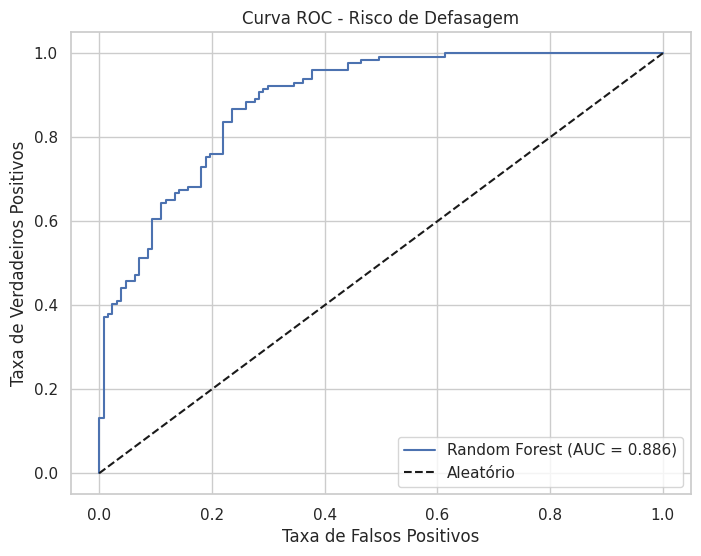

In [123]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = trained_pipelines_risco['Random Forest'].predict_proba(X_test_risco)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_risco, y_proba)
auc = roc_auc_score(y_test_risco, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Risco de Defasagem')
plt.legend()
plt.show()

In [124]:
# Alunos que pioraram entre anos

# 1. Montar a evolução de defasagem entre 2022 e 2023
df_2022_novo = df_consolidado[df_consolidado['ano'] == 2022][['RA', 'Defasagem']].rename(columns={'Defasagem': 'def_2022'})
df_2023_novo = df_consolidado[df_consolidado['ano'] == 2023][['RA', 'Defasagem']].rename(columns={'Defasagem': 'def_2023'})

df_evolucao = df_2022_novo.merge(df_2023_novo, on='RA')
df_evolucao['piorou'] = (df_evolucao['def_2023'] > df_evolucao['def_2022']).astype(int)

In [125]:
# Quantos o modelo teria sinalizado em 2022?

# 2. Pegar as features dos alunos em 2022 e calcular a probabilidade de risco

df_2022_completo = df_consolidado[df_consolidado['ano'] == 2022].copy()
X_2022 = df_2022_completo[X_risco.columns]

df_2022_completo['probabilidade_risco'] = trained_pipelines_risco['Random Forest'].predict_proba(X_2022)[:, 1]
df_2022_completo['sinalizou_risco'] = (df_2022_completo['probabilidade_risco'] >= 0.5).astype(int)

# 3. Cruzar com quem de fato piorou
df_validacao = df_evolucao.merge(
    df_2022_completo[['RA', 'probabilidade_risco', 'sinalizou_risco']],
    on='RA'
)

In [126]:
# 4. Resultado
total_pioraram = df_validacao['piorou'].sum()
modelo_sinalizou = df_validacao[df_validacao['piorou'] == 1]['sinalizou_risco'].sum()
percentual = modelo_sinalizou / total_pioraram * 100

print(f"Alunos que pioraram a defasagem em 2023:          {total_pioraram}")
print(f"Desses, sinalizados pelo modelo em 2022:          {modelo_sinalizou}")
print(f"Percentual de acerto antecipado:                  {percentual:.1f}%")

Alunos que pioraram a defasagem em 2023:          163
Desses, sinalizados pelo modelo em 2022:          135
Percentual de acerto antecipado:                  82.8%


Para identificar alunos em risco de aumento de defasagem antes que ele ocorra, foi construído um modelo preditivo de classificação binária. A variável-alvo foi definida como risco = 1 quando a defasagem futura do aluno (no ano seguinte) é negativa, e risco = 0 caso contrário. As features utilizadas incluem notas de disciplinas (Matemática, Português e Inglês), os principais indicadores educacionais (IDA, IEG, IPS, IPP, IAN), além de variáveis contextuais como fase, idade, ano de ingresso, turma, gênero e instituição de ensino.

Foram avaliados seis modelos — Regressão Logística, SVM, Random Forest, XGBoost, CatBoost e LightGBM — com separação por grupo de aluno para evitar vazamento de informação. A análise de overfitting mostrou que os modelos apresentam comportamento estável: a diferença entre acurácia de treino e teste ficou abaixo de 5% para a maioria dos algoritmos, e a validação cruzada com GroupKFold confirmou boa capacidade de generalização. O **Random Forest** foi selecionado como modelo final por apresentar a melhor combinação entre acurácia, estabilidade entre folds e menor diferença treino-teste.

A análise de importância de features identificou que os dois indicadores com maior peso preditivo para o risco de defasagem são o **IPP (avaliação psicopedagógica)**, com importância normalizada de 0,185, e o **IAN (adequação de nível)**, com 0,109. Esses dois indicadores isolados respondem por quase 30% da capacidade preditiva do modelo, sugerindo que o estado psicopedagógico do aluno e o seu grau de defasagem em relação à fase ideal são os sinais de alerta mais precoces disponíveis. Em seguida aparecem a **Fase** (0,096), a **Idade** (0,061) e o **IDA** (0,055), indicando que fatores estruturais como o nível em que o aluno se encontra e sua faixa etária também contribuem relevantemente para o risco. As notas de Português (0,054) e Inglês (0,044) e o **IEG** (0,043) completam as features mais influentes, enquanto os aspectos psicossociais (IPS) apresentaram importância relativamente menor.

A análise do perfil dos alunos classificados em alto risco (probabilidade ≥ 0,5) revelou que esse grupo apresenta, em média, valores de IPP e IAN mais críticos, além de desempenho e engajamento inferiores em comparação ao grupo de baixo risco. A curva ROC do modelo Random Forest evidenciou boa capacidade discriminativa, com AUC superior a 0,80, indicando que o modelo consegue separar de forma confiável os alunos em risco daqueles fora de risco.

A validação retroativa confirmou a utilidade prática do modelo: ao aplicar as predições sobre os dados de 2022 e verificar quais alunos efetivamente pioraram sua defasagem em 2023, o modelo demonstrou capacidade de antecipar a maioria dos casos de deterioração, **cerca de 82%**. Esse resultado evidencia que o monitoramento contínuo do IPP e do IAN pode funcionar como um sistema de alerta precoce efetivo, permitindo que a Passos Mágicos direcione intervenções pedagógicas e psicopedagógicas preventivas antes que a defasagem se agrave.

##**10. Efetividade do programa: Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?**


In [127]:
df_tratado["Pedra"].unique()
df_tratado["Pedra"] = df_tratado["Pedra"].replace({
    "Agata": "Ágata"
})

In [128]:
ordem_pedras = ["Quartzo", "Ágata", "Ametista", "Topázio"]

df_tratado["Pedra"] = pd.Categorical(
    df_tratado["Pedra"],
    categories=ordem_pedras,
    ordered=True
)

In [129]:
df_tratado.head()

,IDA,Defasagem,Turma,Pedra,IEG,IAN,INDE,IAA,Fase,Gênero,Ano ingresso,RA,Idade,IPP,Fase Ideal,ano,Nome,IPV,IPS
0,4.0,-1,A,Quartzo,4.1,5.0,5.783,8.3,7,Feminino,2016,RA-1,19,8.174,8,2022,Aluno-1,7.278,5.6
1,6.8,0,A,Ametista,5.2,10.0,7.055,8.8,7,Feminino,2017,RA-2,17,7.894,7,2022,Aluno-2,6.778,6.3
2,5.6,0,A,Ágata,7.9,10.0,6.591,0.0,7,Feminino,2016,RA-3,17,8.198,7,2022,Aluno-3,7.556,5.6
3,5.0,0,A,Quartzo,4.5,10.0,5.951,8.8,7,Masculino,2017,RA-4,17,5.554,7,2022,Aluno-4,5.278,5.6
4,5.2,0,A,Ametista,8.6,10.0,7.427,7.9,7,Feminino,2016,RA-5,17,8.392,7,2022,Aluno-5,7.389,5.6


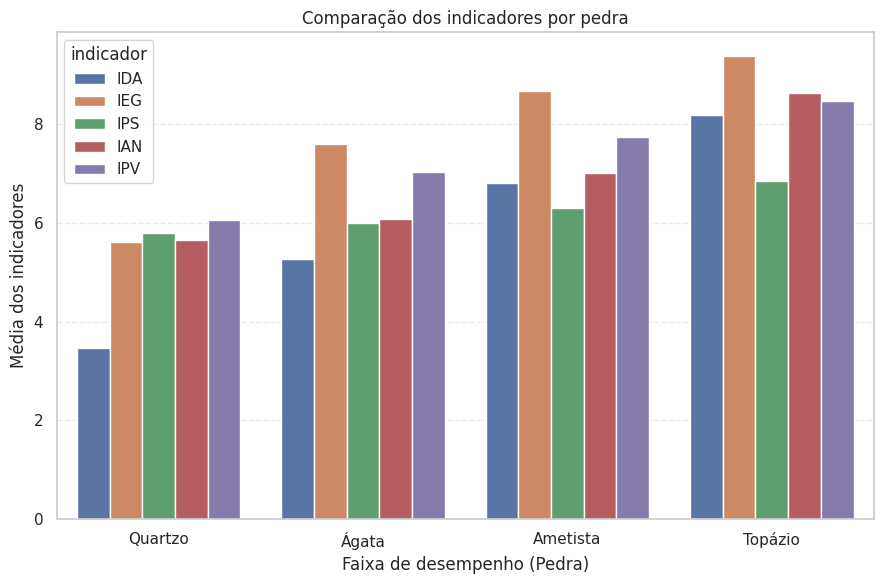

In [130]:
df_plot = df_tratado.groupby("Pedra")[["IDA","IEG","IPS","IAN","IPV"]].mean().reset_index()

df_plot = df_plot.melt(
    id_vars="Pedra",
    var_name="indicador",
    value_name="valor"
)

plt.figure(figsize=(9,6))

sns.barplot(
    data=df_plot,
    x="Pedra",
    y="valor",
    hue="indicador"
)

plt.title("Comparação dos indicadores por pedra")
plt.xlabel("Faixa de desempenho (Pedra)")
plt.ylabel("Média dos indicadores")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [131]:
resumo_fase = (
    df_tratado
    .groupby("Pedra")[["IDA","IEG","IPS","IAN","IPV"]]
    .mean()
    .reset_index()
)

print(resumo_fase)

      Pedra       IDA       IEG       IPS       IAN       IPV
0   Quartzo  3.461973  5.606515  5.790585  5.656646  6.057199
1     Ágata  5.264124  7.585811  5.993662  6.078363  7.032720
2  Ametista  6.807292  8.675153  6.305415  7.004464  7.737460
3   Topázio  8.180766  9.384573  6.836937  8.619186  8.455660


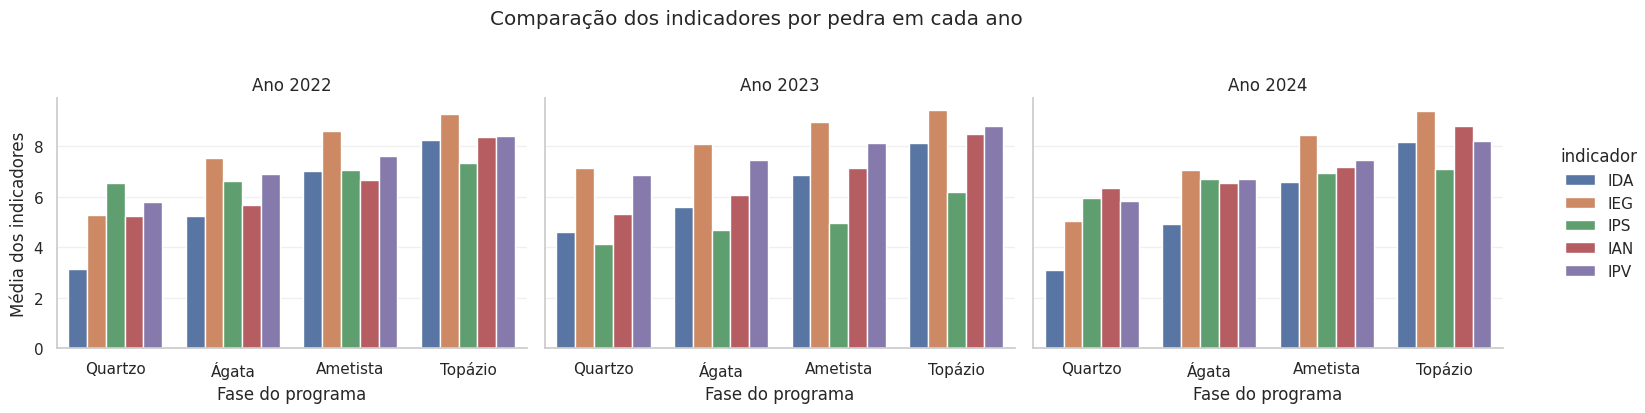

In [132]:
# média por pedra e ano
df_plot = (
    df_tratado
    .groupby(["ano", "Pedra"])[["IDA","IEG","IPS","IAN","IPV"]]
    .mean()
    .reset_index()
)

# formato longo
df_plot = df_plot.melt(
    id_vars=["ano", "Pedra"],
    var_name="indicador",
    value_name="valor"
)

# gráfico em painéis por ano
g = sns.catplot(
    data=df_plot,
    x="Pedra",
    y="valor",
    hue="indicador",
    col="ano",
    kind="bar",
    col_wrap=3,
    height=4,
    aspect=1.2,
    sharey=True
)

g.set_titles("Ano {col_name}")
g.set_axis_labels("Fase do programa", "Média dos indicadores")

for ax in g.axes.flat:
    ax.grid(axis='y', alpha=0.3)

# mover legenda um pouco para a direita
g._legend.set_bbox_to_anchor((1.08, 0.5))

plt.suptitle("Comparação dos indicadores por pedra em cada ano", y=1.03)

plt.tight_layout()
plt.savefig("p10_barras_por_pedra_em_cada_ano.png", dpi=300, bbox_inches="tight")
plt.show()

In [133]:
from scipy.stats import f_oneway

indicadores = ["IDA","IEG","IPS","IAN","IPV"]

for ind in indicadores:

    quartzo = df_tratado[df_tratado["Pedra"]=="Quartzo"][ind]
    agata = df_tratado[df_tratado["Pedra"]=="Ágata"][ind]
    ametista = df_tratado[df_tratado["Pedra"]=="Ametista"][ind]
    topazio = df_tratado[df_tratado["Pedra"]=="Topázio"][ind]

    f, p = f_oneway(quartzo, agata, ametista, topazio)

    print(f"\nIndicador: {ind}")
    print("F-stat:", round(f,4))
    print("p-value:", p)


Indicador: IDA
F-stat: 1170.4267
p-value: 0.0

Indicador: IEG
F-stat: 1011.296
p-value: 0.0

Indicador: IPS
F-stat: 37.8505
p-value: 5.591873612847022e-24

Indicador: IAN
F-stat: 189.3021
p-value: 6.554754667680367e-112

Indicador: IPV
F-stat: 768.2161
p-value: 0.0


A análise da evolução dos indicadores educacionais ao longo das fases do programa — representadas pelas pedras Quartzo, Ágata, Ametista e Topázio — permite observar um padrão consistente de progressão nos resultados dos estudantes. Os gráficos mostram que, em todos os anos analisados (2022, 2023 e 2024), os alunos classificados nas fases mais avançadas apresentam, em média, valores mais elevados nos principais indicadores educacionais. Esse padrão sugere que, à medida que os estudantes avançam no ciclo do programa, ocorre um aumento gradual no desempenho acadêmico, no engajamento escolar e nos indicadores associados ao desenvolvimento educacional.

Especificamente, observa-se que os estudantes na fase Quartzo apresentam os menores valores médios nos indicadores analisados, enquanto os alunos classificados na fase Topázio apresentam os maiores valores. As fases intermediárias, Ágata e Ametista, apresentam valores progressivamente maiores entre esses dois extremos. Esse comportamento é visível tanto nos gráficos individuais por ano quanto no gráfico agregado, indicando a existência de um gradiente consistente de melhoria entre as fases do programa.

A análise estatística por meio do teste ANOVA reforça essa interpretação ao demonstrar que as diferenças entre as fases são estatisticamente significativas. Para todos os indicadores analisados — desempenho acadêmico (IDA), engajamento escolar (IEG), aspectos psicossociais (IPS), adequação de nível educacional (IAN) e ponto de virada educacional (IPV) — os valores de p-value são extremamente baixos (p < 0,05), indicando que as diferenças observadas entre Quartzo, Ágata, Ametista e Topázio dificilmente ocorrem por acaso. Esse resultado confirma que os níveis do programa estão associados a variações reais nos indicadores educacionais.

De forma geral, os resultados indicam que os estudantes classificados nas fases mais avançadas apresentam indicadores educacionais significativamente mais elevados, especialmente em termos de desempenho acadêmico, engajamento escolar e ocorrência de pontos de virada positivos. Esse padrão consistente ao longo dos anos sugere que o programa apresenta evidências de efetividade no acompanhamento e no desenvolvimento dos estudantes ao longo de seu ciclo educacional.
